In [2]:
import pandas as pd
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kstest, levene

# Get powers - Without gamma

## Whitout normalization and unharmonized

Format long

In [ ]:
# format Long
power_ar_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power\power_Argentina_rs_long.feather")
power_cl_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power\power_Chile_rs_long.feather")
power_srm_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power\power_Oslo_resteyesc_long.feather")

power_bio_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power\power_Medellin_hd_CE_long.feather")
power_bio_ctr_long = power_bio_long[(power_bio_long['group'] == 'CTR') | (power_bio_long['group'] == 'G2')].reset_index(drop=True)
power_bio_dta_long = power_bio_long[(power_bio_long['group'] == 'DTA')].reset_index(drop=True)
power_bio_mci_long = power_bio_long[(power_bio_long['group'] == 'DCL') | (power_bio_long['group'] == 'G1')].reset_index(drop=True)

power_por_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power\power_Medellin_ld_CE_long.feather") 
power_por_ctr_long = power_por_long[(power_por_long['group'] == 'CTR') | (power_por_long['group'] == 'GU')].reset_index(drop=True)
power_por_mci_long = power_por_long[(power_por_long['group'] == 'DCL')].reset_index(drop=True)

power_poland_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power\power_Poland_rest_long.feather")
power_chmbp_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power\power_Cuba_protmap_long.feather")

power_skorea_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power\power_CAUEEG_rs_long.feather")

# Datos usando columnas
print('Subjects CL: ',len(power_cl_long.subject.unique()))
print('Subjects AR:',len(power_ar_long.subject.unique()))
print('Subjects SRM: ',len(power_srm_long.subject.unique()))
print('Subjects BIO CTR',len(power_bio_ctr_long.subject.unique()))
print('Subjects BIO DTA',len(power_bio_dta_long.subject.unique()))
print('Subjects BIO MCI',len(power_bio_mci_long.subject.unique()))
print('Subjects POR CTR',len(power_por_ctr_long.subject.unique()))
print('Subjects POR MCI',len(power_por_mci_long.subject.unique()))
print('Subjects CHMBP',len(power_chmbp_long.subject.unique()))
print('Subjects POLAND',len(power_poland_long.subject.unique()))
print('Subjects KOREAN CTR',len(power_skorea_long.subject.unique())) # Ojo no todos son HC

TOTAL_CTR =len(power_cl_long.subject.unique())+len(power_ar_long.subject.unique())+len(power_srm_long.subject.unique())+len(power_bio_ctr_long.subject.unique())+len(power_por_ctr_long.subject.unique())+len(power_chmbp_long.subject.unique())+len(power_poland_long.subject.unique())
print('TOTAL CONTROLES:',TOTAL_CTR)

Subjects CL:  13
Subjects AR: 19
Subjects SRM:  111
Subjects BIO CTR 72
Subjects BIO DTA 8
Subjects BIO MCI 40
Subjects POR CTR 50
Subjects POR MCI 7
Subjects CHMBP 247
Subjects POLAND 77
Subjects KOREAN CTR 1345
TOTAL CONTROLES: 589


Format columns

In [5]:
power_cl = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power\power_Chile_rs_columns.feather")
power_cl.drop(['education','laterality','diagnosis'],inplace=True,axis=1)
power_cl.dropna(inplace=True)

power_ar= pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power\power_Argentina_rs_columns.feather")
power_ar.drop(['education','laterality','diagnosis'],inplace=True,axis=1)
power_ar.dropna(inplace=True)

power_srm = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power\power_Oslo_resteyesc_columns.feather")
power_srm.drop(['ravlt_1', 'ravlt_5', 'ravlt_tot', 'ravlt_imm',
       'ravlt_del', 'ravlt_rec', 'ravlt_fp', 'ds_forw', 'ds_back', 'ds_seq',
       'ds_tot', 'tmt_2', 'tmt_3', 'tmt_4', 'cw_1', 'cw_2', 'cw_3', 'cw_4',
       'vf_1', 'vf_2', 'vf_3'],inplace=True,axis=1)

power_bio = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power\power_Medellin_hd_CE_columns.feather")
power_bio=power_bio[power_bio.visit == 'V0'].reset_index(drop=True)
power_bio.drop(['education', 'MM_total', 'FAS_F', 'FAS_A', 'FAS_S','visit'],inplace=True,axis=1)
power_bio_ctr = power_bio[(power_bio['group'] == 'CTR') | (power_bio['group'] == 'G2')].reset_index(drop=True)
power_bio_ctr.dropna(inplace=True)
power_bio_dta = power_bio[(power_bio['group'] == 'DTA')].reset_index(drop=True)
power_bio_dta.dropna(inplace=True)
power_bio_mci = power_bio[(power_bio['group'] == 'DCL') | (power_bio['group'] == 'G1')].reset_index(drop=True)
power_bio_mci.dropna(inplace=True)

power_por = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power\power_Medellin_ld_CE_columns.feather") 
power_por.drop(['Escolaridad','MMSE_total'],inplace=True,axis=1)
power_por_ctr = power_por[(power_por['group'] == 'CTR') | (power_por['group'] == 'GU')].reset_index(drop=True)
power_por_ctr.dropna(inplace=True)
power_por_mci = power_por[(power_por['group'] == 'DCL')].reset_index(drop=True)
power_por_mci.dropna(inplace=True)

power_poland = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power\power_Poland_rest_columns.feather")
power_poland.drop(['education'],inplace=True,axis=1)
power_poland.dropna(inplace=True)

power_chmbp = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power\power_Cuba_protmap_columns.feather")
power_chmbp.drop(['Weight lb', 'Education Level '],inplace=True,axis=1)
power_chmbp.dropna(inplace=True)


power_skorea = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power\power_CAUEEG_rs_columns.feather")
power_skorea.drop(['level_1','level_2','site'],inplace=True,axis=1)
power_skorea['Site'] = 'Korea'
power_skorea.dropna(inplace=True)

# Renombrar columnas T5 por P7 y T6 por P8
power_skorea.columns = power_skorea.columns.str.replace('T5', 'P7')
power_skorea.columns = power_skorea.columns.str.replace('T6', 'P8')

# Datos usando columnas
print('Subjects CL: ',len(power_cl.subject.unique()))
print('Subjects AR:',len(power_ar.subject.unique()))
print('Subjects SRM: ',len(power_srm.subject.unique()))
print('Subjects BIO CTR',len(power_bio_ctr.subject.unique()))
print('Subjects BIO DTA',len(power_bio_dta.subject.unique()))
print('Subjects BIO MCI',len(power_bio_mci.subject.unique()))
print('Subjects POR CTR',len(power_por_ctr.subject.unique()))
print('Subjects POR MCI',len(power_por_mci.subject.unique()))
print('Subjects CHMBP',len(power_chmbp.subject.unique()))
print('Subjects POLAND',len(power_poland.subject.unique()))
print('SUBJECTS KOREAN CTR',len(power_skorea.subject.unique()))

TOTAL_CTR =len(power_cl.subject.unique())+len(power_ar.subject.unique())+len(power_srm.subject.unique())+len(power_bio_ctr.subject.unique())+len(power_por_ctr.subject.unique())+len(power_chmbp.subject.unique())+len(power_poland.subject.unique())+len(power_skorea.subject.unique())
print('TOTAL CONTROLES:',TOTAL_CTR)

Subjects CL:  13
Subjects AR: 19
Subjects SRM:  111
Subjects BIO CTR 65
Subjects BIO DTA 0
Subjects BIO MCI 39
Subjects POR CTR 50
Subjects POR MCI 7
Subjects CHMBP 247
Subjects POLAND 77
SUBJECTS KOREAN CTR 446
TOTAL CONTROLES: 1028


In [6]:
df_unharmonized_wogamma= pd.concat((power_por_ctr,power_bio_ctr,power_cl,power_ar,power_srm,power_poland,power_chmbp,power_skorea))
df_unharmonized_wogamma.drop(['sex'],inplace=True,axis=1)
df_unharmonized_wogamma.to_csv(r'D:\MulticentersEEG\Features_2_normativeModel\unharmonized_power_wogamma_data.csv', index=False)

features_rpower = list(df_unharmonized_wogamma.columns[3:-4])
features_rpower = [feature for feature in features_rpower if not any(substring in feature for substring in ["C3", "C4", "FP1", "FP2"])]

## With normalization : Z-score

Format long

In [9]:
# format Long
power_zscore_ar_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power_zscore\power_Argentina_rs_zscore_long.feather")
power_zscore_cl_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power_zscore\power_Chile_rs_zscore_long.feather")
power_zscore_srm_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power_zscore\power_Oslo_resteyesc_zscore_long.feather")

power_zscore_bio_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power_zscore\power_Medellin_hd_CE_zscore_long.feather")
power_zscore_bio_ctr_long = power_zscore_bio_long[(power_zscore_bio_long['group'] == 'CTR') | (power_zscore_bio_long['group'] == 'G2')].reset_index(drop=True)
power_zscore_bio_dta_long = power_zscore_bio_long[(power_zscore_bio_long['group'] == 'DTA')].reset_index(drop=True)
power_zscore_bio_mci_long = power_zscore_bio_long[(power_zscore_bio_long['group'] == 'DCL') | (power_zscore_bio_long['group'] == 'G1')].reset_index(drop=True)

power_zscore_por_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power_zscore\power_Medellin_ld_CE_zscore_long.feather") 
power_zscore_por_ctr_long = power_zscore_por_long[(power_zscore_por_long['group'] == 'CTR') | (power_zscore_por_long['group'] == 'GU')].reset_index(drop=True)
power_zscore_por_mci_long = power_zscore_por_long[(power_zscore_por_long['group'] == 'DCL')].reset_index(drop=True)

power_zscore_poland_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power_zscore\power_Poland_rest_zscore_long.feather")
power_zscore_chmbp_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power_zscore\power_Cuba_protmap_zscore_long.feather")

power_zscore_skorea_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power_zscore\power_CAUEEG_rs_zscore_long.feather")

# Datos usando columnas
print('Subjects CL: ',len(power_zscore_cl_long.subject.unique()))
print('Subjects AR:',len(power_zscore_ar_long.subject.unique()))
print('Subjects SRM: ',len(power_zscore_srm_long.subject.unique()))
print('Subjects BIO CTR',len(power_zscore_bio_ctr_long.subject.unique()))
print('Subjects BIO DTA',len(power_zscore_bio_dta_long.subject.unique()))
print('Subjects BIO MCI',len(power_zscore_bio_mci_long.subject.unique()))
print('Subjects POR CTR',len(power_zscore_por_ctr_long.subject.unique()))
print('Subjects POR MCI',len(power_zscore_por_mci_long.subject.unique()))
print('Subjects CHMBP',len(power_zscore_chmbp_long.subject.unique()))
print('Subjects POLAND',len(power_zscore_poland_long.subject.unique()))
print('Subjects KOREAN CTR',len(power_zscore_skorea_long.subject.unique())) # Ojo no todos son HC

TOTAL_CTR =len(power_zscore_cl_long.subject.unique())+len(power_zscore_ar_long.subject.unique())+len(power_zscore_srm_long.subject.unique())+len(power_zscore_bio_ctr_long.subject.unique())+len(power_zscore_por_ctr_long.subject.unique())+len(power_zscore_chmbp_long.subject.unique())+len(power_zscore_poland_long.subject.unique())
print('TOTAL CONTROLES:',TOTAL_CTR)

Subjects CL:  13
Subjects AR: 19
Subjects SRM:  111
Subjects BIO CTR 72
Subjects BIO DTA 8
Subjects BIO MCI 40
Subjects POR CTR 50
Subjects POR MCI 7
Subjects CHMBP 247
Subjects POLAND 77
Subjects KOREAN CTR 1345
TOTAL CONTROLES: 589


Format columns

In [10]:
power_zscore_cl = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power_zscore\power_Chile_rs_zscore_columns.feather")
power_zscore_cl.drop(['education','laterality','diagnosis'],inplace=True,axis=1)
power_zscore_cl.dropna(inplace=True)

power_zscore_ar= pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power_zscore\power_Argentina_rs_zscore_columns.feather")
power_zscore_ar.drop(['education','laterality','diagnosis'],inplace=True,axis=1)
power_zscore_ar.dropna(inplace=True)

power_zscore_srm = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power_zscore\power_Oslo_resteyesc_zscore_columns.feather")
power_zscore_srm.drop(['ravlt_1', 'ravlt_5', 'ravlt_tot', 'ravlt_imm',
       'ravlt_del', 'ravlt_rec', 'ravlt_fp', 'ds_forw', 'ds_back', 'ds_seq',
       'ds_tot', 'tmt_2', 'tmt_3', 'tmt_4', 'cw_1', 'cw_2', 'cw_3', 'cw_4',
       'vf_1', 'vf_2', 'vf_3'],inplace=True,axis=1)

power_zscore_bio = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power_zscore\power_Medellin_hd_CE_zscore_columns.feather")
power_zscore_bio=power_zscore_bio[power_zscore_bio.visit == 'V0'].reset_index(drop=True)
power_zscore_bio.drop(['education', 'MM_total', 'FAS_F', 'FAS_A', 'FAS_S','visit'],inplace=True,axis=1)
power_zscore_bio_ctr = power_zscore_bio[(power_zscore_bio['group'] == 'CTR') | (power_zscore_bio['group'] == 'G2')].reset_index(drop=True)
power_zscore_bio_ctr.dropna(inplace=True)
power_zscore_bio_dta = power_zscore_bio[(power_zscore_bio['group'] == 'DTA')].reset_index(drop=True)
power_zscore_bio_dta.dropna(inplace=True)
power_zscore_bio_mci = power_zscore_bio[(power_zscore_bio['group'] == 'DCL') | (power_zscore_bio['group'] == 'G1')].reset_index(drop=True)
power_zscore_bio_mci.dropna(inplace=True)

power_zscore_por = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power_zscore\power_Medellin_ld_CE_zscore_columns.feather") 
power_zscore_por.drop(['Escolaridad','MMSE_total'],inplace=True,axis=1)
power_zscore_por_ctr = power_zscore_por[(power_zscore_por['group'] == 'CTR') | (power_zscore_por['group'] == 'GU')].reset_index(drop=True)
power_zscore_por_ctr.dropna(inplace=True)
power_zscore_por_mci = power_zscore_por[(power_zscore_por['group'] == 'DCL')].reset_index(drop=True)
power_zscore_por_mci.dropna(inplace=True)

power_zscore_poland = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power_zscore\power_Poland_rest_zscore_columns.feather")
power_zscore_poland.drop(['education'],inplace=True,axis=1)
power_zscore_poland.dropna(inplace=True)

power_zscore_chmbp = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power_zscore\power_Cuba_protmap_zscore_columns.feather")
power_zscore_chmbp.drop(['Weight lb', 'Education Level '],inplace=True,axis=1)
power_zscore_chmbp.dropna(inplace=True)


power_zscore_skorea = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\without_gamma\power_zscore\power_CAUEEG_rs_zscore_columns.feather")
power_zscore_skorea.drop(['level_1','level_2','site'],inplace=True,axis=1)
power_zscore_skorea['Site'] = 'Korea'
power_zscore_skorea.dropna(inplace=True)

# Renombrar columnas T5 por P7 y T6 por P8
power_zscore_skorea.columns = power_zscore_skorea.columns.str.replace('T5', 'P7')
power_zscore_skorea.columns = power_zscore_skorea.columns.str.replace('T6', 'P8')

# Datos usando columnas
print('Subjects CL: ',len(power_zscore_cl.subject.unique()))
print('Subjects AR:',len(power_zscore_ar.subject.unique()))
print('Subjects SRM: ',len(power_zscore_srm.subject.unique()))
print('Subjects BIO CTR',len(power_zscore_bio_ctr.subject.unique()))
print('Subjects BIO DTA',len(power_zscore_bio_dta.subject.unique()))
print('Subjects BIO MCI',len(power_zscore_bio_mci.subject.unique()))
print('Subjects POR CTR',len(power_zscore_por_ctr.subject.unique()))
print('Subjects POR MCI',len(power_zscore_por_mci.subject.unique()))
print('Subjects CHMBP',len(power_zscore_chmbp.subject.unique()))
print('Subjects POLAND',len(power_zscore_poland.subject.unique()))
print('SUBJECTS KOREAN CTR',len(power_zscore_skorea.subject.unique()))

TOTAL_CTR =len(power_zscore_cl.subject.unique())+len(power_zscore_ar.subject.unique())+len(power_zscore_srm.subject.unique())+len(power_zscore_bio_ctr.subject.unique())+len(power_zscore_por_ctr.subject.unique())+len(power_zscore_chmbp.subject.unique())+len(power_zscore_poland.subject.unique())+len(power_zscore_skorea.subject.unique())
print('TOTAL CONTROLES:',TOTAL_CTR)

Subjects CL:  13
Subjects AR: 19
Subjects SRM:  111
Subjects BIO CTR 65
Subjects BIO DTA 0
Subjects BIO MCI 39
Subjects POR CTR 50
Subjects POR MCI 7
Subjects CHMBP 247
Subjects POLAND 77
SUBJECTS KOREAN CTR 446
TOTAL CONTROLES: 1028


In [11]:
df_zscore_wogamma= pd.concat((power_zscore_por_ctr,power_zscore_bio_ctr,power_zscore_cl,power_zscore_ar,power_zscore_srm,power_zscore_poland,power_zscore_chmbp,power_zscore_skorea))
df_zscore_wogamma.drop(['sex'],inplace=True,axis=1)
df_zscore_wogamma.to_csv(r'D:\MulticentersEEG\Features_2_normativeModel\without_gamma\unharmonized_zscore_power_wogamma_data.csv', index=False)

features_rpower = list(df_zscore_wogamma.columns[3:-3])
features_rpower = [feature for feature in features_rpower if not any(substring in feature for substring in ["C3", "C4", "FP1", "FP2"])]
print(len(features_rpower),features_rpower)

28 ['O1_Alpha-1', 'O1_Alpha-2', 'O1_Beta1', 'O1_Beta2', 'O1_Beta3', 'O1_Delta', 'O1_Theta', 'O2_Alpha-1', 'O2_Alpha-2', 'O2_Beta1', 'O2_Beta2', 'O2_Beta3', 'O2_Delta', 'O2_Theta', 'P7_Alpha-1', 'P7_Alpha-2', 'P7_Beta1', 'P7_Beta2', 'P7_Beta3', 'P7_Delta', 'P7_Theta', 'P8_Alpha-1', 'P8_Alpha-2', 'P8_Beta1', 'P8_Beta2', 'P8_Beta3', 'P8_Delta', 'P8_Theta']


In [13]:
df_zscore_wogamma

,subject,Task,group,C3_Alpha-1,C3_Alpha-2,C3_Beta1,C3_Beta2,C3_Beta3,C3_Delta,C3_Theta,...,P8_Alpha-1,P8_Alpha-2,P8_Beta1,P8_Beta2,P8_Beta3,P8_Delta,P8_Theta,center,age,Site
0,sub-CTR001,CE,CTR,0.121657,0.102937,0.182296,0.051893,0.158367,0.289971,0.092878,...,0.129438,0.125516,0.203690,0.058035,0.115334,0.282630,0.085357,Medellin_ld,42.0,Medellin_ld
1,sub-CTR002,CE,CTR,0.327860,0.117483,0.086960,0.034799,0.075503,0.241005,0.116390,...,0.231354,0.108697,0.129977,0.060174,0.164566,0.214876,0.090356,Medellin_ld,31.0,Medellin_ld
2,sub-CTR003,CE,CTR,0.264450,0.061892,0.140108,0.041555,0.079178,0.197722,0.215096,...,0.279577,0.084203,0.141184,0.038601,0.073690,0.171264,0.211482,Medellin_ld,59.0,Medellin_ld
3,sub-CTR004,CE,CTR,0.110166,0.072726,0.173092,0.054625,0.099068,0.350905,0.139419,...,0.108709,0.088422,0.211713,0.060722,0.107949,0.283854,0.138632,Medellin_ld,68.0,Medellin_ld
4,sub-CTR005,CE,CTR,0.134646,0.158882,0.267920,0.060185,0.070185,0.237210,0.070972,...,0.199091,0.173963,0.195254,0.043783,0.068183,0.249604,0.070122,Medellin_ld,59.0,Medellin_ld
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1297,sub-01341,rs,HC,0.178996,0.117678,0.127550,0.039109,0.052808,0.357208,0.126651,...,0.270801,0.170691,0.100157,0.033921,0.044671,0.263378,0.116380,CAUEEG,67.0,Korea
1300,sub-01344,rs,HC,0.237019,0.110350,0.118081,0.049499,0.157503,0.167025,0.160523,...,0.398119,0.077384,0.098319,0.027330,0.055659,0.099082,0.244108,CAUEEG,63.0,Korea
1304,sub-01348,rs,HC,0.164871,0.074594,0.095751,0.036483,0.104411,0.393015,0.130875,...,0.406243,0.090263,0.065120,0.017978,0.018803,0.149301,0.252292,CAUEEG,66.0,Korea
1311,sub-01355,rs,HC,0.109089,0.077837,0.128603,0.027439,0.045954,0.493373,0.117704,...,0.191085,0.068256,0.105621,0.024478,0.031853,0.440728,0.137978,CAUEEG,75.0,Korea


In [131]:
with PdfPages("D:\MulticentersEEG\Features_2_normativeModel\without_gamma\linealidad_without_gamma.pdf") as pdf:
    for feature in features_rpower:
        data = df_zscore_wogamma[[feature, 'age', 'Site']].dropna()
        y = data[feature]
        
        # Crear figura personalizada
        fig, ax = plt.subplots(figsize=(8, 6))  # Ajustar tamaño
        for site in data['Site'].unique():
            site_data = data[data['Site'] == site]
            sns.regplot(
                x='age', 
                y=feature, 
                data=site_data, 
                ax=ax, 
                label=site,
                ci=None,
                scatter_kws={'alpha': 0.6}, 
                line_kws={'linewidth': 2}
            )
        
        # Agregar título y leyenda
        ax.set_title(f"Relación lineal entre edad y {feature}", fontsize=12)
        ax.legend(title="Site")
        
        # Ajustar diseño para evitar recortes
        plt.tight_layout()
        
        # Guardar la figura en el PDF
        pdf.savefig(fig)
        
        # Cerrar la figura
        plt.close(fig)

print("Reporte guardado como reporte.pdf")


Reporte guardado como reporte.pdf


## Neurocombat 

In [ ]:
from sklearn.preprocessing import LabelEncoder
le_center = LabelEncoder()
le_center.fit(df_zscore_wogamma['Site'])
print(list(le_center.classes_))

from sklearn.preprocessing import LabelEncoder

cols = ['Site']
le = LabelEncoder()
# Encode labels of multiple columns at once
df_zscore_wogamma[cols] = df_zscore_wogamma[cols].apply(le.fit_transform)

df_zscore_wogamma.head()

['Argentina', 'Chile', 'Cuba', 'Korea', 'Medellin_ld', 'Medellín_hd', 'Oslo', 'Poland']


In [155]:
from neurocombat_sklearn import CombatModel
cb_model = CombatModel()
data =df_zscore_wogamma.iloc[:, 3:-3].to_numpy()
# Fitting model
cb_model.fit(data,
             df_zscore_wogamma[['Site']],
             df_zscore_wogamma[['age']])

# Harmonize data over hc group
data_combat = cb_model.transform(data,
                                df_zscore_wogamma[['Site']],
                                df_zscore_wogamma[['age']])

d:\flujo_portables\env\lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
d:\flujo_portables\env\lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [156]:
data_combat_df = pd.DataFrame(data_combat, columns=df_zscore_wogamma.columns[3:-3])

# Concatenar data_combat_df con las últimas tres columnas de data_columns
combat_df_wogamma_wosex = pd.concat([data_combat_df, df_zscore_wogamma.iloc[:, 0:3].reset_index(drop=True),df_zscore_wogamma.iloc[:, -3:].reset_index(drop=True)], axis=1)
combat_df_wogamma_wosex.to_csv(r'D:\MulticentersEEG\Features_2_normativeModel\without_gamma\neurocombat_power_wogamma_data.csv', index=False)

In [145]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

pca_unharmonized = PCA(n_components=10)
pca_result_unharmonized = pca_unharmonized.fit_transform(df_unharmonized_wogamma.iloc[:,3:-5].values)

df_unharmonized_wogamma['pca-one'] = pca_result_unharmonized[:,0]
df_unharmonized_wogamma['pca-two'] = pca_result_unharmonized[:,1]
explained_variance_unharmonized = np.cumsum(pca_unharmonized.explained_variance_ratio_)


pca_zscore = PCA(n_components=10)
pca_result = pca_zscore.fit_transform(df_zscore_wogamma.iloc[:,3:-4].values)

df_zscore_wogamma['pca-one'] = pca_result[:,0]
df_zscore_wogamma['pca-two'] = pca_result[:,1]
explained_variance_original = np.cumsum(pca_zscore.explained_variance_ratio_)


pca_harmonized = PCA(n_components=10)
harmonized_pca_result = pca_harmonized.fit_transform(data_combat_df.iloc[:,3:-6].values)

combat_df_wogamma_wosex['harmonized-pca-one'] = harmonized_pca_result[:,0]
combat_df_wogamma_wosex['harmonized-pca-two'] = harmonized_pca_result[:,1]
explained_variance_harmonized = np.cumsum(pca_harmonized.explained_variance_ratio_)


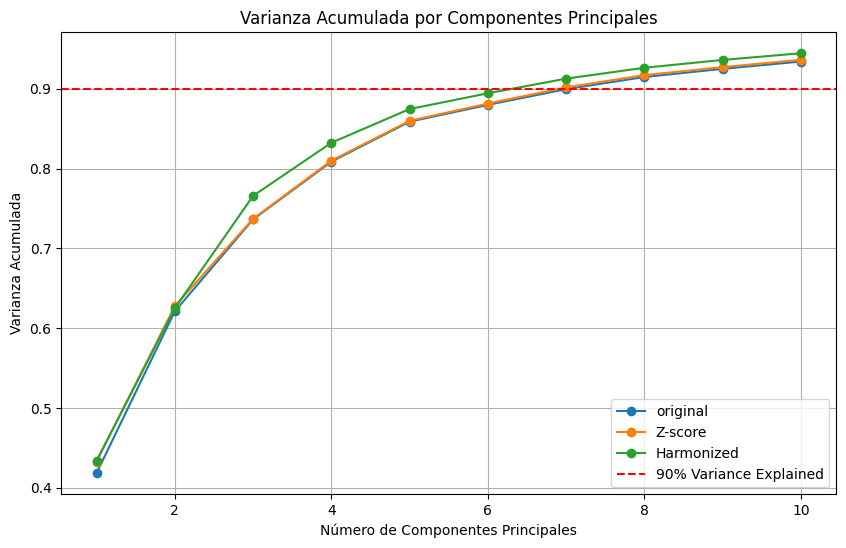

In [146]:
# Graficar la varianza acumulada
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(explained_variance_unharmonized) + 1),
    explained_variance_unharmonized,
    marker='o',
    label='original'
)
plt.plot(
    range(1, len(explained_variance_original) + 1),
    explained_variance_original,
    marker='o',
    label='Z-score'
)
plt.plot(
    range(1, len(explained_variance_harmonized) + 1),
    explained_variance_harmonized,
    marker='o',
    label='Harmonized'
)

plt.axhline(y=0.9, color='r', linestyle='--', label='90% Variance Explained')
plt.title('Varianza Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada')
plt.legend(loc='best')
plt.grid()
plt.show()

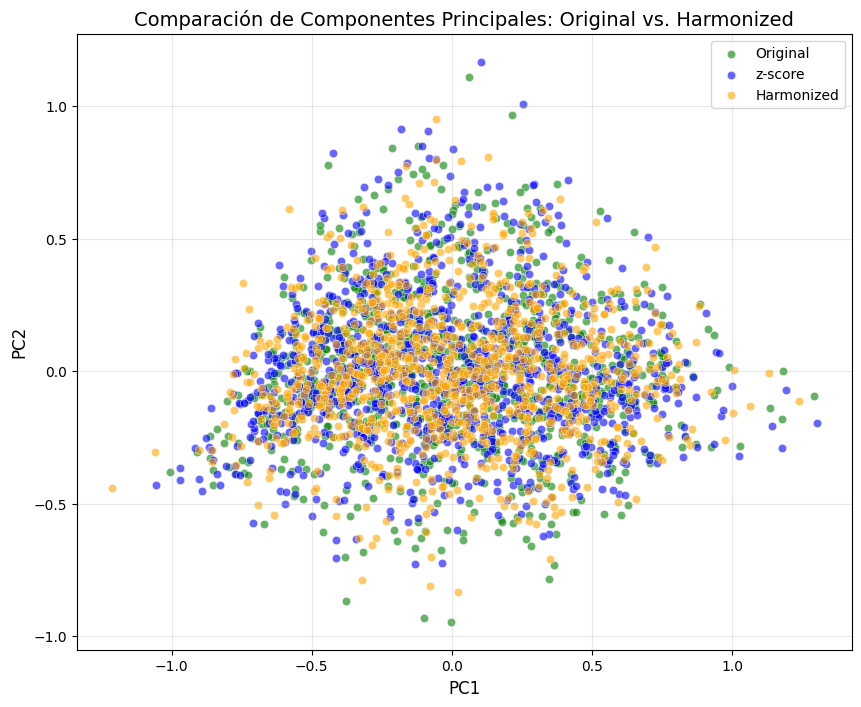

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un gráfico comparativo de PC1 vs PC2
plt.figure(figsize=(10, 8))

# Datos originales
sns.scatterplot(
    x=df_unharmonized_wogamma['pca-one'],
    y=df_unharmonized_wogamma['pca-two'],
    color='green',
    alpha=0.6,
    label='Original'
)

# Datos zscore
sns.scatterplot(
    x=df_zscore_wogamma['pca-one'],
    y=df_zscore_wogamma['pca-two'],
    color='blue',
    alpha=0.6,
    label='z-score'
)

# Datos armonizados
sns.scatterplot(
    x=combat_df_wogamma_wosex['harmonized-pca-one'],
    y=combat_df_wogamma_wosex['harmonized-pca-two'],
    color='orange',
    alpha=0.6,
    label='Harmonized'
)

# Añadir títulos y etiquetas
plt.title('Comparación de Componentes Principales: Original vs. Harmonized', fontsize=14)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()


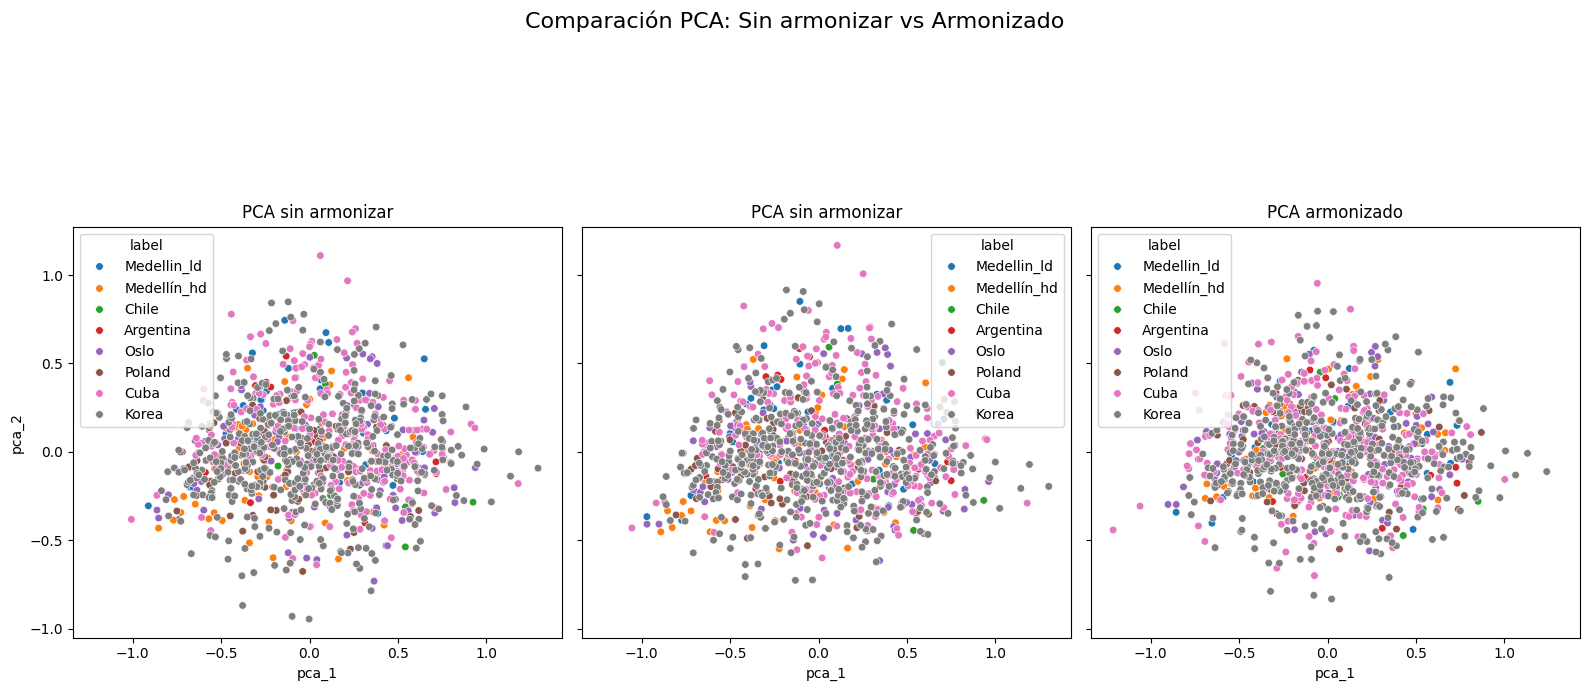

In [148]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import pairwise_distances

pca_raw_unharmonized = pd.DataFrame({
    'pca_1': df_unharmonized_wogamma['pca-one'],
    'pca_2': df_unharmonized_wogamma['pca-two'],
    'label': df_unharmonized_wogamma['Site']
})

pca_raw_df = pd.DataFrame({
    'pca_1': df_zscore_wogamma['pca-one'],
    'pca_2': df_zscore_wogamma['pca-two'],
    'label': le_center.inverse_transform(df_zscore_wogamma['Site'])
})

pca_harmonized_df = pd.DataFrame({
    'pca_1': combat_df_wogamma_wosex['harmonized-pca-one'],
    'pca_2': combat_df_wogamma_wosex['harmonized-pca-two'],
    'label': le_center.inverse_transform(combat_df_wogamma_wosex['Site'])
})

# Calcular la distancia euclidiana promedio
unharmonized_coords = pca_raw_unharmonized[['pca_1', 'pca_2']].values
raw_coords = pca_raw_df[['pca_1', 'pca_2']].values
harmonized_coords = pca_harmonized_df[['pca_1', 'pca_2']].values

# Crear subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 8), sharex=True, sharey=True)

# Gráfico de PCA sin armonizar
sns.scatterplot(
    x='pca_1', y='pca_2', hue='label', data=pca_raw_unharmonized, ax=axes[0], s=30, palette='tab10'
)
axes[0].set_title('PCA sin armonizar')
axes[0].set_aspect('equal')

#Grafico de PCA Z-score
sns.scatterplot(
    x='pca_1', y='pca_2', hue='label', data=pca_raw_df, ax=axes[1], s=30, palette='tab10'
)
axes[1].set_title('PCA sin armonizar')
axes[1].set_aspect('equal')

# Gráfico de PCA armonizado
sns.scatterplot(
    x='pca_1', y='pca_2', hue='label', data=pca_harmonized_df, ax=axes[2], s=30, palette='tab10'
)
axes[2].set_title('PCA armonizado')
axes[2].set_aspect('equal')

# # Ajustes generales
# for ax in axes:
#     lim = (
#         min(pca_raw_df[['pca_1', 'pca_2']].min().min(), pca_harmonized_df[['pca_1', 'pca_2']].min().min()) - 5,
#         max(pca_raw_df[['pca_1', 'pca_2']].max().max(), pca_harmonized_df[['pca_1', 'pca_2']].max().max()) + 5
#     )
#     ax.set_xlim(lim)
#     ax.set_ylim(lim)
#     ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)

plt.suptitle('Comparación PCA: Sin armonizar vs Armonizado', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


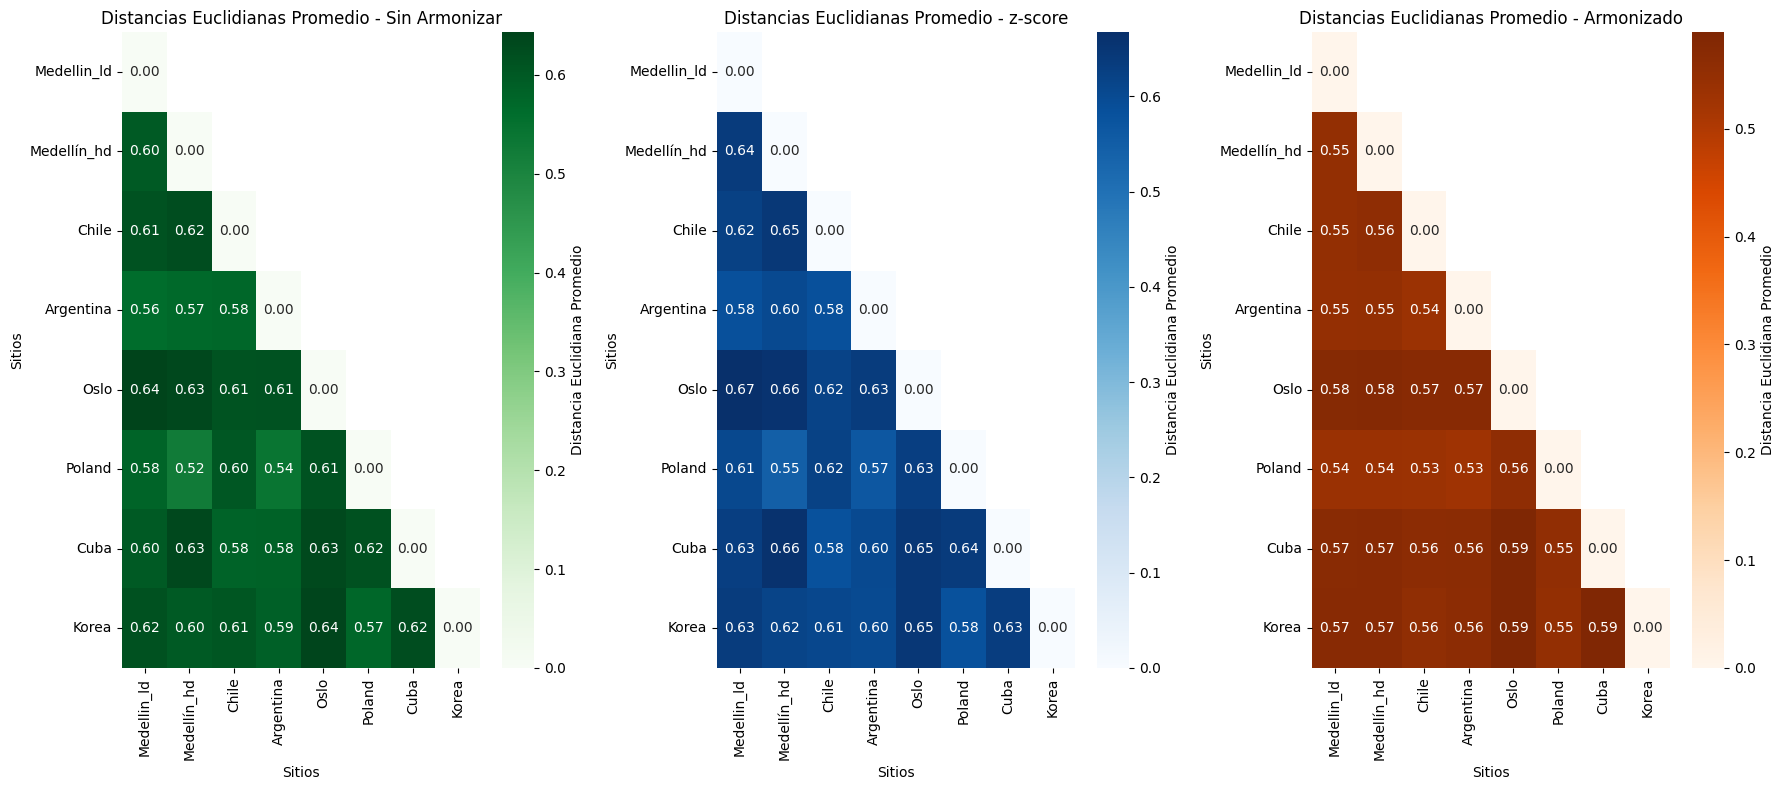

In [149]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Obtener etiquetas únicas de los sitios
sites = df_zscore_wogamma['Site'].unique()
site_labels = le_center.inverse_transform(sites)

# Crear DataFrames para PCA por sitio
unharmonized_coords_by_site = {
    site: pca_raw_unharmonized[pca_raw_unharmonized['label'] == le_center.inverse_transform([site])[0]][['pca_1', 'pca_2']].values
    for site in sites
}


raw_coords_by_site = {
    site: pca_raw_df[pca_raw_df['label'] == le_center.inverse_transform([site])[0]][['pca_1', 'pca_2']].values
    for site in sites
}

harmonized_coords_by_site = {
    site: pca_harmonized_df[pca_harmonized_df['label'] == le_center.inverse_transform([site])[0]][['pca_1', 'pca_2']].values
    for site in sites
}

# Función para calcular la distancia euclidiana promedio entre sitios
def compute_mean_distances(coords_by_site):
    n_sites = len(sites)
    distance_matrix = np.zeros((n_sites, n_sites))
    
    for i, site_i in enumerate(sites):
        for j, site_j in enumerate(sites):
            if i != j:
                distances = pairwise_distances(coords_by_site[site_i], coords_by_site[site_j], metric='euclidean')
                distance_matrix[i, j] = distances.mean()
            else:
                distance_matrix[i, j] = 0  # Distancia con uno mismo es 0
    
    return distance_matrix

# Función para crear la máscara de la parte inferior de la diagonal
def mask_lower_triangle(matrix):
    mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)
    return mask

# Calcular matrices de distancia promedio
unharmonized_distance_matrix = compute_mean_distances(unharmonized_coords_by_site)
raw_distance_matrix = compute_mean_distances(raw_coords_by_site)
harmonized_distance_matrix = compute_mean_distances(harmonized_coords_by_site)

# Crear DataFrames para graficar
unharmonized_distance_df = pd.DataFrame(unharmonized_distance_matrix, index=site_labels, columns=site_labels)
raw_distance_df = pd.DataFrame(raw_distance_matrix, index=site_labels, columns=site_labels)
harmonized_distance_df = pd.DataFrame(harmonized_distance_matrix, index=site_labels, columns=site_labels)

# Crear la máscara para enmascarar la parte inferior de la diagonal
unharmonized_mask = mask_lower_triangle(unharmonized_distance_df.values)
raw_mask = mask_lower_triangle(raw_distance_df.values)
harmonized_mask = mask_lower_triangle(harmonized_distance_df.values)

# Graficar matrices como mapas de calor (solo un lado de la diagonal)
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

sns.heatmap(
    unharmonized_distance_df, annot=True, fmt=".2f", cmap="Greens", ax=axes[0],
    mask=unharmonized_mask, cbar_kws={'label': 'Distancia Euclidiana Promedio'}
)
axes[0].set_title("Distancias Euclidianas Promedio - Sin Armonizar")
axes[0].set_xlabel("Sitios")
axes[0].set_ylabel("Sitios")

sns.heatmap(
    raw_distance_df, annot=True, fmt=".2f", cmap="Blues", ax=axes[1],
    mask=raw_mask, cbar_kws={'label': 'Distancia Euclidiana Promedio'}
)
axes[1].set_title("Distancias Euclidianas Promedio - z-score")
axes[1].set_xlabel("Sitios")
axes[1].set_ylabel("Sitios")

sns.heatmap(
    harmonized_distance_df, annot=True, fmt=".2f", cmap="Oranges", ax=axes[2],
    mask=harmonized_mask, cbar_kws={'label': 'Distancia Euclidiana Promedio'}
)
axes[2].set_title("Distancias Euclidianas Promedio - Armonizado")
axes[2].set_xlabel("Sitios")
axes[2].set_ylabel("Sitios")

plt.tight_layout()
plt.show()


### Validación de supuestos y ANCOVA

* El ANCOVA permite evaluar si hay diferencias en la variable dependiente entre los sitios ajustando por la variación en la edad.

* Prueba de Levene: A diferencia de la prueba de Bartlett, la prueba de Levene no requiere que los datos sigan una distribución normal. Calcula la varianza de las diferencias absolutas entre los valores de cada grupo y su mediana.


In [ ]:
from pingouin import ancova, homoscedasticity
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kstest, levene

# Crear tabla para almacenar resultados de los supuestos
supuestos = pd.DataFrame(columns=["Feature",'ks_stat_unharmonized','ks_pval_unharmonized','ks_unharmonized','levene_stat_unharmonized','levene_pval_unharmonized','Levene_unharmonized','ks_stat_zscore','ks_pval_zscore','ks_zscore','levene_stat_zscore','levene_pval_zscore','Levene_zscore','ks_Harmonized','ks_stat_Harmonized','ks_pval_Harmonized','levene_stat_Harmonized','levene_pval_Harmonized','levene_Harmonized'])

# Realizar ANCOVA y validar supuestos para cada variable dependiente
for feature in features_rpower:
    data_unharmonize = df_unharmonized_wogamma[[feature, 'age', 'Site']].dropna()
    data_zscore = df_zscore_wogamma[[feature, 'age', 'Site']].dropna()
    data_harmonize = combat_df_wogamma_wosex[[feature, 'age', 'Site']].dropna()
    y_unharmonize = data_unharmonize[feature]
    y_zscore = data_zscore[feature]
    y_harmonize = data_harmonize[feature]
    
    # 1. Normalidad con Kolmogorov-Smirnov
    ks_stat_unharmonized, ks_pval_unharmonized = kstest(y_unharmonize, 'norm', args=(y.mean(), y.std()))
    Norm_unharmonized = "Normal" if ks_pval_unharmonized >= 0.05 else "No normal"
    
    ks_stat, ks_pval = kstest(y_zscore, 'norm', args=(y.mean(), y.std()))
    Norm_zscore = "Normal" if ks_pval >= 0.05 else "No normal"
    
    ks_stat_harmonized, ks_pval_harmonized = kstest(y_harmonize, 'norm', args=(y.mean(), y.std()))
    Norm_Harmonized = "Normal" if ks_pval >= 0.05 else "No normal"
    
    # 2. Homogeneidad de varianzas con Levene
    grouped_data_unharmonize = [data_unharmonize[data_unharmonize['Site'] == site][feature] for site in data_unharmonize['Site'].unique()]
    levene_stat_unharmonized, levene_pval_unharmonized = levene(*grouped_data_unharmonize)
    Hom_unharmonized = "Homocedástico" if levene_pval_unharmonized >= 0.05 else "Heterocedástico"
    
    grouped_data_zscore = [data_zscore[data_zscore['Site'] == site][feature] for site in data_zscore['Site'].unique()]
    levene_stat, levene_pval = levene(*grouped_data_zscore)
    Hom_zscore = "Homocedástico" if levene_pval >= 0.05 else "Heterocedástico"
    
    grouped_data_harmonize = [data_harmonize[data_harmonize['Site'] == site][feature] for site in data_harmonize['Site'].unique()]
    levene_stat_harmonized, levene_pval_harmonized = levene(*grouped_data_harmonize)
    Hom_Harmonized = "Homocedástico" if levene_pval_harmonized >= 0.05 else "Heterocedástico"

    
    # Guardar resultados en la tabla de supuestos
    supuestos = pd.concat([
        supuestos, 
        pd.DataFrame({
            "Feature": [feature],
            "ks_stat_unharmonized": [ks_stat_unharmonized],
            "ks_pval_unharmonized": [ks_pval_unharmonized],
            "ks_unharmonized": [Norm_unharmonized],
            "levene_stat_unharmonized": [levene_stat_unharmonized],
            "levene_pval_unharmonized": [levene_pval_unharmonized],
            "Levene_unharmonized": [Hom_unharmonized],
            "ks_stat_zscore": [ks_stat],
            "ks_pval_zscore": [ks_pval],
            "ks_zscore": [Norm_zscore],
            "levene_stat_zscore": [levene_stat],
            "levene_pval_zscore": [levene_pval],
            "Levene_zscore": [Hom_zscore],
            "ks_Harmonized": [Norm_Harmonized],
            "ks_stat_Harmonized": [ks_stat_harmonized],
            "ks_pval_Harmonized": [ks_pval_harmonized],
            "levene_stat_Harmonized": [levene_stat_harmonized],
            "levene_pval_Harmonized": [levene_pval_harmonized],
            "levene_Harmonized": [Hom_Harmonized]
        })
    ], ignore_index=True)

supuestos.to_excel(r'D:\MulticentersEEG\Features_2_normativeModel\without_gamma\val_supuestos_neurocombat_wogamma_wosex.xlsx', index=False)


C:\Users\Luisa\AppData\Local\Temp\ipykernel_12228\2960974046.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  supuestos = pd.concat([


# Get the power - WITH GAMMA 40 Hz

## Whitout normalization and unharmonized

format long

In [ ]:
# format Long
power_ar_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power\power_Argentina_rs_long.feather")
power_cl_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power\power_Chile_rs_long.feather")
power_srm_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power\power_Oslo_resteyesc_long.feather")

power_bio_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power\power_Medellin_hd_CE_long.feather")
power_bio_ctr_long = power_bio_long[(power_bio_long['group'] == 'CTR') | (power_bio_long['group'] == 'G2')].reset_index(drop=True)
power_bio_dta_long = power_bio_long[(power_bio_long['group'] == 'DTA')].reset_index(drop=True)
power_bio_mci_long = power_bio_long[(power_bio_long['group'] == 'DCL') | (power_bio_long['group'] == 'G1')].reset_index(drop=True)

power_por_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power\power_Medellin_ld_CE_long.feather") 
power_por_ctr_long = power_por_long[(power_por_long['group'] == 'CTR') | (power_por_long['group'] == 'GU')].reset_index(drop=True)
power_por_mci_long = power_por_long[(power_por_long['group'] == 'DCL')].reset_index(drop=True)

power_poland_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power\power_Poland_rest_long.feather")
power_chmbp_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power\power_Cuba_protmap_long.feather")

power_skorea_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power\power_CAUEEG_rs_long.feather")

power_dortmund_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power\power_Dortmund_rs_long.feather")

# Datos usando columnas
print('Subjects CL: ',len(power_cl_long.subject.unique()))
print('Subjects AR:',len(power_ar_long.subject.unique()))
print('Subjects SRM: ',len(power_srm_long.subject.unique()))
print('Subjects BIO CTR',len(power_bio_ctr_long.subject.unique()))
print('Subjects BIO DTA',len(power_bio_dta_long.subject.unique()))
print('Subjects BIO MCI',len(power_bio_mci_long.subject.unique()))
print('Subjects POR CTR',len(power_por_ctr_long.subject.unique()))
print('Subjects POR MCI',len(power_por_mci_long.subject.unique()))
print('Subjects CHMBP',len(power_chmbp_long.subject.unique()))
print('Subjects POLAND',len(power_poland_long.subject.unique()))
print('Subjects KOREAN CTR',len(power_skorea_long.subject.unique())) # Ojo no todos son HC
print('Subjects DORTMUND',len(power_dortmund_long.subject.unique()))
TOTAL_CTR =len(power_cl_long.subject.unique())+len(power_ar_long.subject.unique())+len(power_srm_long.subject.unique())+len(power_bio_ctr_long.subject.unique())+len(power_por_ctr_long.subject.unique())+len(power_chmbp_long.subject.unique())+len(power_poland_long.subject.unique())
print('TOTAL CONTROLES:',TOTAL_CTR)

Subjects CL:  13
Subjects AR: 19
Subjects SRM:  111
Subjects BIO CTR 72
Subjects BIO DTA 8
Subjects BIO MCI 40
Subjects POR CTR 50
Subjects POR MCI 7
Subjects CHMBP 247
Subjects POLAND 77
Subjects KOREAN CTR 1345
TOTAL CONTROLES: 589


Format columns

In [19]:
power_cl = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power\power_Chile_rs_columns.feather")
power_cl.drop(['education','laterality','diagnosis'],inplace=True,axis=1)
power_cl.dropna(inplace=True)

power_ar= pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power\power_Argentina_rs_columns.feather")
power_ar.drop(['education','laterality','diagnosis'],inplace=True,axis=1)
power_ar.dropna(inplace=True)

power_srm = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power\power_Oslo_resteyesc_columns.feather")
power_srm.drop(['ravlt_1', 'ravlt_5', 'ravlt_tot', 'ravlt_imm',
       'ravlt_del', 'ravlt_rec', 'ravlt_fp', 'ds_forw', 'ds_back', 'ds_seq',
       'ds_tot', 'tmt_2', 'tmt_3', 'tmt_4', 'cw_1', 'cw_2', 'cw_3', 'cw_4',
       'vf_1', 'vf_2', 'vf_3'],inplace=True,axis=1)

power_bio = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power\power_Medellin_hd_CE_columns.feather")
power_bio=power_bio[power_bio.visit == 'V0'].reset_index(drop=True)
power_bio.drop(['education', 'MM_total', 'FAS_F', 'FAS_A', 'FAS_S','visit'],inplace=True,axis=1)
power_bio_ctr = power_bio[(power_bio['group'] == 'CTR') | (power_bio['group'] == 'G2')].reset_index(drop=True)
power_bio_ctr.dropna(inplace=True)
power_bio_dta = power_bio[(power_bio['group'] == 'DTA')].reset_index(drop=True)
power_bio_dta.dropna(inplace=True)
power_bio_mci = power_bio[(power_bio['group'] == 'DCL') | (power_bio['group'] == 'G1')].reset_index(drop=True)
power_bio_mci.dropna(inplace=True)

power_por = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power\power_Medellin_ld_CE_columns.feather") 
power_por.drop(['Escolaridad','MMSE_total'],inplace=True,axis=1)
power_por_ctr = power_por[(power_por['group'] == 'CTR') | (power_por['group'] == 'GU')].reset_index(drop=True)
power_por_ctr.dropna(inplace=True)
power_por_mci = power_por[(power_por['group'] == 'DCL')].reset_index(drop=True)
power_por_mci.dropna(inplace=True)

power_poland = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power\power_Poland_rest_columns.feather")
power_poland.drop(['education'],inplace=True,axis=1)
power_poland.dropna(inplace=True)

power_chmbp = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power\power_Cuba_protmap_columns.feather")
power_chmbp.drop(['Weight lb', 'Education Level '],inplace=True,axis=1)
power_chmbp.dropna(inplace=True)


power_skorea = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power\power_CAUEEG_rs_columns.feather")
power_skorea.drop(['level_1','level_2','site'],inplace=True,axis=1)
power_skorea['Site'] = 'Korea'
power_skorea.dropna(inplace=True)

# Renombrar columnas T5 por P7 y T6 por P8
power_skorea.columns = power_skorea.columns.str.replace('T5', 'P7')
power_skorea.columns = power_skorea.columns.str.replace('T6', 'P8')

# Datos usando columnas
print('Subjects CL: ',len(power_cl.subject.unique()))
print('Subjects AR:',len(power_ar.subject.unique()))
print('Subjects SRM: ',len(power_srm.subject.unique()))
print('Subjects BIO CTR',len(power_bio_ctr.subject.unique()))
print('Subjects BIO DTA',len(power_bio_dta.subject.unique()))
print('Subjects BIO MCI',len(power_bio_mci.subject.unique()))
print('Subjects POR CTR',len(power_por_ctr.subject.unique()))
print('Subjects POR MCI',len(power_por_mci.subject.unique()))
print('Subjects CHMBP',len(power_chmbp.subject.unique()))
print('Subjects POLAND',len(power_poland.subject.unique()))
print('SUBJECTS KOREAN CTR',len(power_skorea.subject.unique()))

TOTAL_CTR =len(power_cl.subject.unique())+len(power_ar.subject.unique())+len(power_srm.subject.unique())+len(power_bio_ctr.subject.unique())+len(power_por_ctr.subject.unique())+len(power_chmbp.subject.unique())+len(power_poland.subject.unique())+len(power_skorea.subject.unique())
print('TOTAL CONTROLES:',TOTAL_CTR)

Subjects CL:  13
Subjects AR: 19
Subjects SRM:  111
Subjects BIO CTR 65
Subjects BIO DTA 0
Subjects BIO MCI 39
Subjects POR CTR 50
Subjects POR MCI 7
Subjects CHMBP 247
Subjects POLAND 77
SUBJECTS KOREAN CTR 446
TOTAL CONTROLES: 1028


In [20]:
df_unharmonized_gamma40= pd.concat((power_por_ctr,power_bio_ctr,power_cl,power_ar,power_srm,power_poland,power_chmbp,power_skorea))
df_unharmonized_gamma40.drop(['sex'],inplace=True,axis=1)
df_unharmonized_gamma40.to_csv(r'D:\MulticentersEEG\Features_2_normativeModel\gamma_40\unharmonized_power_gamma40_data.csv', index=False)

features_rpower = list(df_unharmonized_gamma40.columns[3:-4])
features_rpower = [feature for feature in features_rpower if not any(substring in feature for substring in ["C3", "C4", "FP1", "FP2"])]

## With normalization : Z-score

Format long

In [21]:
# format Long
power_zscore_ar_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power_zscore\power_Argentina_rs_zscore_long.feather")
power_zscore_cl_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power_zscore\power_Chile_rs_zscore_long.feather")
power_zscore_srm_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power_zscore\power_Oslo_resteyesc_zscore_long.feather")

power_zscore_bio_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power_zscore\power_Medellin_hd_CE_zscore_long.feather")
power_zscore_bio_ctr_long = power_zscore_bio_long[(power_zscore_bio_long['group'] == 'CTR') | (power_zscore_bio_long['group'] == 'G2')].reset_index(drop=True)
power_zscore_bio_dta_long = power_zscore_bio_long[(power_zscore_bio_long['group'] == 'DTA')].reset_index(drop=True)
power_zscore_bio_mci_long = power_zscore_bio_long[(power_zscore_bio_long['group'] == 'DCL') | (power_zscore_bio_long['group'] == 'G1')].reset_index(drop=True)

power_zscore_por_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power_zscore\power_Medellin_ld_CE_zscore_long.feather") 
power_zscore_por_ctr_long = power_zscore_por_long[(power_zscore_por_long['group'] == 'CTR') | (power_zscore_por_long['group'] == 'GU')].reset_index(drop=True)
power_zscore_por_mci_long = power_zscore_por_long[(power_zscore_por_long['group'] == 'DCL')].reset_index(drop=True)

power_zscore_poland_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power_zscore\power_Poland_rest_zscore_long.feather")
power_zscore_chmbp_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power_zscore\power_Cuba_protmap_zscore_long.feather")

power_zscore_skorea_long = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power_zscore\power_CAUEEG_rs_zscore_long.feather")

# Datos usando columnas
print('Subjects CL: ',len(power_zscore_cl_long.subject.unique()))
print('Subjects AR:',len(power_zscore_ar_long.subject.unique()))
print('Subjects SRM: ',len(power_zscore_srm_long.subject.unique()))
print('Subjects BIO CTR',len(power_zscore_bio_ctr_long.subject.unique()))
print('Subjects BIO DTA',len(power_zscore_bio_dta_long.subject.unique()))
print('Subjects BIO MCI',len(power_zscore_bio_mci_long.subject.unique()))
print('Subjects POR CTR',len(power_zscore_por_ctr_long.subject.unique()))
print('Subjects POR MCI',len(power_zscore_por_mci_long.subject.unique()))
print('Subjects CHMBP',len(power_zscore_chmbp_long.subject.unique()))
print('Subjects POLAND',len(power_zscore_poland_long.subject.unique()))
print('Subjects KOREAN CTR',len(power_zscore_skorea_long.subject.unique())) # Ojo no todos son HC

TOTAL_CTR =len(power_zscore_cl_long.subject.unique())+len(power_zscore_ar_long.subject.unique())+len(power_zscore_srm_long.subject.unique())+len(power_zscore_bio_ctr_long.subject.unique())+len(power_zscore_por_ctr_long.subject.unique())+len(power_zscore_chmbp_long.subject.unique())+len(power_zscore_poland_long.subject.unique())
print('TOTAL CONTROLES:',TOTAL_CTR)

Subjects CL:  13
Subjects AR: 19
Subjects SRM:  111
Subjects BIO CTR 72
Subjects BIO DTA 8
Subjects BIO MCI 40
Subjects POR CTR 50
Subjects POR MCI 7
Subjects CHMBP 247
Subjects POLAND 77
Subjects KOREAN CTR 1345
TOTAL CONTROLES: 589


Format columns

In [29]:
power_zscore_cl = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power_zscore\power_Chile_rs_zscore_columns.feather")
power_zscore_cl.drop(['education','laterality','diagnosis'],inplace=True,axis=1)
power_zscore_cl.dropna(inplace=True)

power_zscore_ar= pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power_zscore\power_Argentina_rs_zscore_columns.feather")
power_zscore_ar.drop(['education','laterality','diagnosis'],inplace=True,axis=1)
power_zscore_ar.dropna(inplace=True)

power_zscore_srm = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power_zscore\power_Oslo_resteyesc_zscore_columns.feather")
power_zscore_srm.drop(['ravlt_1', 'ravlt_5', 'ravlt_tot', 'ravlt_imm',
       'ravlt_del', 'ravlt_rec', 'ravlt_fp', 'ds_forw', 'ds_back', 'ds_seq',
       'ds_tot', 'tmt_2', 'tmt_3', 'tmt_4', 'cw_1', 'cw_2', 'cw_3', 'cw_4',
       'vf_1', 'vf_2', 'vf_3'],inplace=True,axis=1)

power_zscore_bio = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power_zscore\power_Medellin_hd_CE_zscore_columns.feather")
power_zscore_bio=power_zscore_bio[power_zscore_bio.visit == 'V0'].reset_index(drop=True)
power_zscore_bio.drop(['education', 'MM_total', 'FAS_F', 'FAS_A', 'FAS_S','visit'],inplace=True,axis=1)
power_zscore_bio_ctr = power_zscore_bio[(power_zscore_bio['group'] == 'CTR') | (power_zscore_bio['group'] == 'G2')].reset_index(drop=True)
power_zscore_bio_ctr.dropna(inplace=True)
power_zscore_bio_dta = power_zscore_bio[(power_zscore_bio['group'] == 'DTA')].reset_index(drop=True)
power_zscore_bio_dta.dropna(inplace=True)
power_zscore_bio_mci = power_zscore_bio[(power_zscore_bio['group'] == 'DCL') | (power_zscore_bio['group'] == 'G1')].reset_index(drop=True)
power_zscore_bio_mci.dropna(inplace=True)

power_zscore_por = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power_zscore\power_Medellin_ld_CE_zscore_columns.feather") 
power_zscore_por.drop(['Escolaridad','MMSE_total'],inplace=True,axis=1)
power_zscore_por_ctr = power_zscore_por[(power_zscore_por['group'] == 'CTR') | (power_zscore_por['group'] == 'GU')].reset_index(drop=True)
power_zscore_por_ctr.dropna(inplace=True)
power_zscore_por_mci = power_zscore_por[(power_zscore_por['group'] == 'DCL')].reset_index(drop=True)
power_zscore_por_mci.dropna(inplace=True)

power_zscore_poland = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power_zscore\power_Poland_rest_zscore_columns.feather")
power_zscore_poland.drop(['education'],inplace=True,axis=1)
power_zscore_poland.dropna(inplace=True)

power_zscore_chmbp = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power_zscore\power_Cuba_protmap_zscore_columns.feather")
power_zscore_chmbp.drop(['Weight lb', 'Education Level '],inplace=True,axis=1)
power_zscore_chmbp.dropna(inplace=True)


power_zscore_skorea = pd.read_feather(r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\power_zscore\power_CAUEEG_rs_zscore_columns.feather")
power_zscore_skorea_mci=power_zscore_skorea[(power_zscore_skorea['group'] == 'MCI')].reset_index(drop=True)
power_zscore_skorea_mci.drop(['level_1','level_2','site'],inplace=True,axis=1)
power_zscore_skorea_mci['Site'] = 'Korea'
power_zscore_skorea_mci.dropna(inplace=True)
power_zscore_skorea_mci.columns = power_zscore_skorea_mci.columns.str.replace('T5', 'P7')
power_zscore_skorea_mci.columns = power_zscore_skorea_mci.columns.str.replace('T6', 'P8')


power_zscore_skorea=power_zscore_skorea[(power_zscore_skorea['group'] == 'HC')].reset_index(drop=True)
power_zscore_skorea.drop(['level_1','level_2','site'],inplace=True,axis=1)
power_zscore_skorea['Site'] = 'Korea'
power_zscore_skorea.dropna(inplace=True)

# # Renombrar columnas T5 por P7 y T6 por P8
power_zscore_skorea.columns = power_zscore_skorea.columns.str.replace('T5', 'P7')
power_zscore_skorea.columns = power_zscore_skorea.columns.str.replace('T6', 'P8')

# Datos usando columnas
print('Subjects CL: ',len(power_zscore_cl.subject.unique()))
print('Subjects AR:',len(power_zscore_ar.subject.unique()))
print('Subjects SRM: ',len(power_zscore_srm.subject.unique()))
print('Subjects BIO CTR',len(power_zscore_bio_ctr.subject.unique()))
print('Subjects BIO DTA',len(power_zscore_bio_dta.subject.unique()))
print('Subjects BIO MCI',len(power_zscore_bio_mci.subject.unique()))
print('Subjects POR CTR',len(power_zscore_por_ctr.subject.unique()))
print('Subjects POR MCI',len(power_zscore_por_mci.subject.unique()))
print('Subjects CHMBP',len(power_zscore_chmbp.subject.unique()))
print('Subjects POLAND',len(power_zscore_poland.subject.unique()))
print('SUBJECTS KOREAN CTR',len(power_zscore_skorea.subject.unique()))
print('SUBJECTS KOREAN MCI',len(power_zscore_skorea_mci.subject.unique()))

TOTAL_CTR =len(power_zscore_cl.subject.unique())+len(power_zscore_ar.subject.unique())+len(power_zscore_srm.subject.unique())+len(power_zscore_bio_ctr.subject.unique())+len(power_zscore_por_ctr.subject.unique())+len(power_zscore_chmbp.subject.unique())+len(power_zscore_poland.subject.unique())+len(power_zscore_skorea.subject.unique())
print('TOTAL CONTROLES:',TOTAL_CTR)

Subjects CL:  13
Subjects AR: 19
Subjects SRM:  111
Subjects BIO CTR 65
Subjects BIO DTA 0
Subjects BIO MCI 39
Subjects POR CTR 50
Subjects POR MCI 7
Subjects CHMBP 247
Subjects POLAND 77
SUBJECTS KOREAN CTR 446
SUBJECTS KOREAN MCI 0
TOTAL CONTROLES: 1028


In [38]:
df_zscore_gamma40= pd.concat((power_zscore_por_ctr,power_zscore_bio_ctr,power_zscore_cl,power_zscore_ar,power_zscore_srm,power_zscore_poland,power_zscore_chmbp,power_zscore_skorea))
df_zscore_gamma40.drop(['sex'],inplace=True,axis=1)
df_zscore_gamma40.to_csv(r'D:\MulticentersEEG\Features_2_normativeModel\gamma_40\unharmonized_zscore_power_gamma40_data.csv', index=False)

features_rpower = list(df_zscore_gamma40.columns[3:-3])
features_rpower = [feature for feature in features_rpower if not any(substring in feature for substring in ["C3", "C4", "FP1", "FP2"])]
print(len(features_rpower),features_rpower)

32 ['O1_Alpha-1', 'O1_Alpha-2', 'O1_Beta1', 'O1_Beta2', 'O1_Beta3', 'O1_Delta', 'O1_Gamma', 'O1_Theta', 'O2_Alpha-1', 'O2_Alpha-2', 'O2_Beta1', 'O2_Beta2', 'O2_Beta3', 'O2_Delta', 'O2_Gamma', 'O2_Theta', 'P7_Alpha-1', 'P7_Alpha-2', 'P7_Beta1', 'P7_Beta2', 'P7_Beta3', 'P7_Delta', 'P7_Gamma', 'P7_Theta', 'P8_Alpha-1', 'P8_Alpha-2', 'P8_Beta1', 'P8_Beta2', 'P8_Beta3', 'P8_Delta', 'P8_Gamma', 'P8_Theta']


C:\Users\Luisa\AppData\Local\Temp\ipykernel_9576\2448057258.py:9: UserWarning: 
The palette list has fewer values (7) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.kdeplot(data=df_zscore_gamma40, x='age', hue='Site', fill=True, common_norm=False, palette=mi_paleta, ax=ax1)
C:\Users\Luisa\AppData\Local\Temp\ipykernel_9576\2448057258.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Site', y='age', data=df_zscore_gamma40, palette=mi_paleta, ax=ax2)
C:\Users\Luisa\AppData\Local\Temp\ipykernel_9576\2448057258.py:17: UserWarning: 
The palette list has fewer values (7) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.swarmplot(x='Site', y='age', data=df_zscore_gamma40, palette=mi_paleta, ax=ax2)
d:\flujo_portables\env\lib\site-packages\seaborn\categorical.py:3398: UserW

Text(843.4608585858584, 0.5, 'Age')

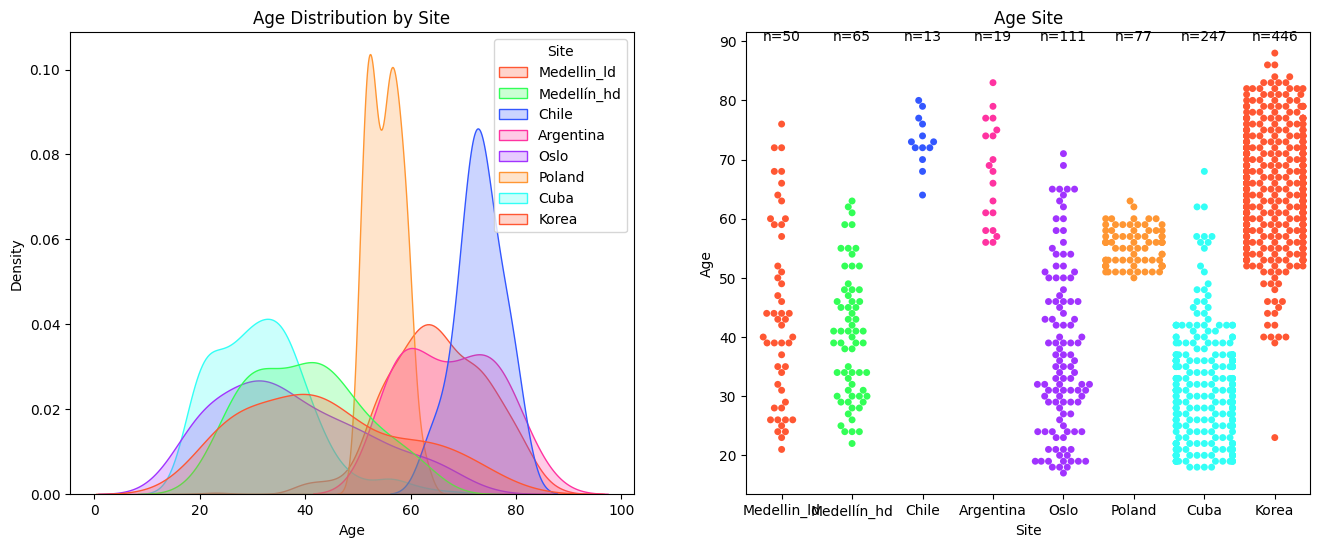

In [24]:
plt.figure(figsize=(16, 6))
vivid_colors = ['#FF5733', '#33FF57', '#3357FF', '#FF33A1', '#A133FF', '#FF9633', '#33FFF6']
colores_personalizados = vivid_colors

mi_paleta = sns.color_palette(colores_personalizados)
# Gráfico de densidad

ax1 = plt.subplot(1, 2, 1)
sns.kdeplot(data=df_zscore_gamma40, x='age', hue='Site', fill=True, common_norm=False, palette=mi_paleta, ax=ax1)
ax1.set_title('Age Distribution by Site')
ax1.set_xlabel('Age')
ax1.set_ylabel('Density')


# Swarmplot
ax2 = plt.subplot(1, 2, 2)
sns.swarmplot(x='Site', y='age', data=df_zscore_gamma40, palette=mi_paleta, ax=ax2)
# Añadir etiquetas con el número de sujetos
for i, group in enumerate(df_zscore_gamma40['Site'].unique()):
    count = df_zscore_gamma40[df_zscore_gamma40['Site'] == group].shape[0]
    ax2.text(i, ax2.get_ylim()[1] -1.95, f'n={count}', ha='center', va='bottom')

ax2.set_title('Age Site')
ax2.set_xlabel('Site')
ax2.set_ylabel('Age')

In [25]:
with PdfPages("D:\MulticentersEEG\Features_2_normativeModel\gamma_40\linealidad_without_gamma.pdf") as pdf:
    for feature in features_rpower:
        data = df_zscore_gamma40[[feature, 'age', 'Site']].dropna()
        y = data[feature]
        
        # Crear figura personalizada
        fig, ax = plt.subplots(figsize=(8, 6))  # Ajustar tamaño
        for site in data['Site'].unique():
            site_data = data[data['Site'] == site]
            sns.regplot(
                x='age', 
                y=feature, 
                data=site_data, 
                ax=ax, 
                label=site,
                ci=None,
                scatter_kws={'alpha': 0.6}, 
                line_kws={'linewidth': 2}
            )
        
        # Agregar título y leyenda
        ax.set_title(f"Relación lineal entre edad y {feature}", fontsize=12)
        ax.legend(title="Site")
        
        # Ajustar diseño para evitar recortes
        plt.tight_layout()
        
        # Guardar la figura en el PDF
        pdf.savefig(fig)
        
        # Cerrar la figura
        plt.close(fig)

print("Reporte guardado como reporte.pdf")


Reporte guardado como reporte.pdf


## NeuroCombat

In [39]:
from sklearn.preprocessing import LabelEncoder
le_center = LabelEncoder()
le_center.fit(df_zscore_gamma40['Site'])
print(list(le_center.classes_))

from sklearn.preprocessing import LabelEncoder

cols = ['Site']
le = LabelEncoder()
# Encode labels of multiple columns at once
df_zscore_gamma40[cols] = df_zscore_gamma40[cols].apply(le.fit_transform)

df_zscore_gamma40.head()

['Argentina', 'Chile', 'Cuba', 'Korea', 'Medellin_ld', 'Medellín_hd', 'Oslo', 'Poland']


,subject,Task,group,C3_Alpha-1,C3_Alpha-2,C3_Beta1,C3_Beta2,C3_Beta3,C3_Delta,C3_Gamma,...,P8_Alpha-2,P8_Beta1,P8_Beta2,P8_Beta3,P8_Delta,P8_Gamma,P8_Theta,center,age,Site
0,sub-CTR001,CE,CTR,0.116022,0.098169,0.173852,0.049490,0.151031,0.276539,0.046323,...,0.117879,0.191297,0.054504,0.108317,0.265434,0.060843,0.080164,Medellin_ld,42.0,4
1,sub-CTR002,CE,CTR,0.306962,0.109995,0.081417,0.032581,0.070690,0.225643,0.063740,...,0.093232,0.111484,0.051613,0.141152,0.184304,0.142277,0.077500,Medellin_ld,31.0,4
2,sub-CTR003,CE,CTR,0.250358,0.058593,0.132642,0.039340,0.074958,0.187185,0.053289,...,0.080859,0.135578,0.037068,0.070764,0.164463,0.039709,0.203084,Medellin_ld,59.0,4
3,sub-CTR004,CE,CTR,0.103259,0.068166,0.162239,0.051200,0.092856,0.328903,0.062701,...,0.081494,0.195126,0.055965,0.099492,0.261615,0.078345,0.127771,Medellin_ld,68.0,4
4,sub-CTR005,CE,CTR,0.131365,0.155011,0.261392,0.058718,0.068475,0.231430,0.024367,...,0.167217,0.187683,0.042085,0.065539,0.239924,0.038779,0.067403,Medellin_ld,59.0,4


In [40]:
from neurocombat_sklearn import CombatModel
cb_model = CombatModel()
data =df_zscore_gamma40.iloc[:, 3:-3].to_numpy()
# Fitting model
cb_model.fit(data,
             df_zscore_gamma40[['Site']],
             df_zscore_gamma40[['age']])

# Harmonize data over hc group
data_combat_gamma40 = cb_model.transform(data,
                                df_zscore_gamma40[['Site']],
                                df_zscore_gamma40[['age']])

d:\flujo_portables\env\lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
d:\flujo_portables\env\lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [41]:
data_combat_df_gamma40 = pd.DataFrame(data_combat_gamma40, columns=df_zscore_gamma40.columns[3:-3])

# Concatenar data_combat_df con las últimas tres columnas de data_columns
combat_df_gamma40_wosex = pd.concat([data_combat_df_gamma40, df_zscore_gamma40.iloc[:, 0:3].reset_index(drop=True),df_zscore_gamma40.iloc[:, -3:].reset_index(drop=True)], axis=1)
combat_df_gamma40_wosex.to_csv(r'D:\MulticentersEEG\Features_2_normativeModel\gamma_40\neurocombat_power_gamma40_data.csv', index=False)

In [42]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

pca_unharmonized = PCA(n_components=10)
pca_result_unharmonized = pca_unharmonized.fit_transform(df_unharmonized_gamma40.iloc[:,3:-5].values)

df_unharmonized_gamma40['pca-one'] = pca_result_unharmonized[:,0]
df_unharmonized_gamma40['pca-two'] = pca_result_unharmonized[:,1]
explained_variance_unharmonized = np.cumsum(pca_unharmonized.explained_variance_ratio_)


pca_zscore = PCA(n_components=10)
pca_result = pca_zscore.fit_transform(df_zscore_gamma40.iloc[:,3:-4].values)

df_zscore_gamma40['pca-one'] = pca_result[:,0]
df_zscore_gamma40['pca-two'] = pca_result[:,1]
explained_variance_original = np.cumsum(pca_zscore.explained_variance_ratio_)


pca_harmonized = PCA(n_components=10)
harmonized_pca_result = pca_harmonized.fit_transform(data_combat_df_gamma40.iloc[:,3:-6].values)

combat_df_gamma40_wosex['harmonized-pca-one'] = harmonized_pca_result[:,0]
combat_df_gamma40_wosex['harmonized-pca-two'] = harmonized_pca_result[:,1]
explained_variance_harmonized = np.cumsum(pca_harmonized.explained_variance_ratio_)


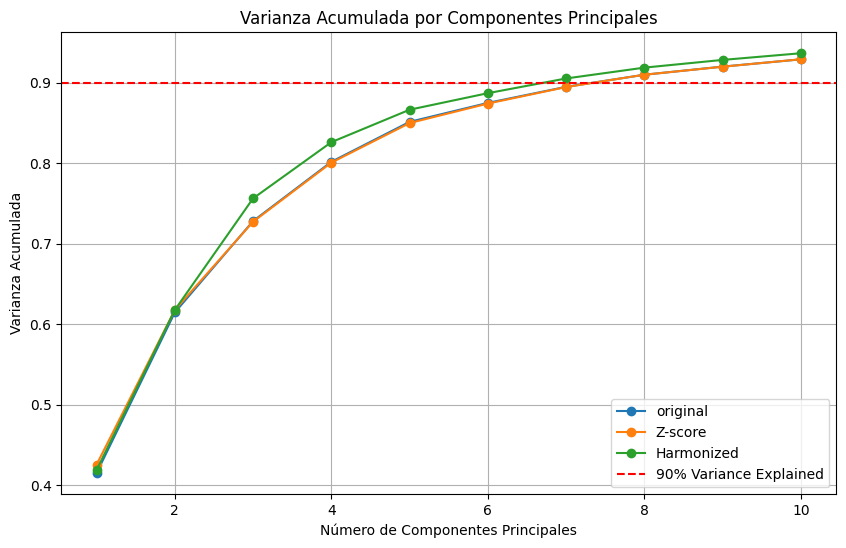

In [43]:
# Graficar la varianza acumulada
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(explained_variance_unharmonized) + 1),
    explained_variance_unharmonized,
    marker='o',
    label='original'
)
plt.plot(
    range(1, len(explained_variance_original) + 1),
    explained_variance_original,
    marker='o',
    label='Z-score'
)
plt.plot(
    range(1, len(explained_variance_harmonized) + 1),
    explained_variance_harmonized,
    marker='o',
    label='Harmonized'
)

plt.axhline(y=0.9, color='r', linestyle='--', label='90% Variance Explained')
plt.title('Varianza Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada')
plt.legend(loc='best')
plt.grid()
plt.show()

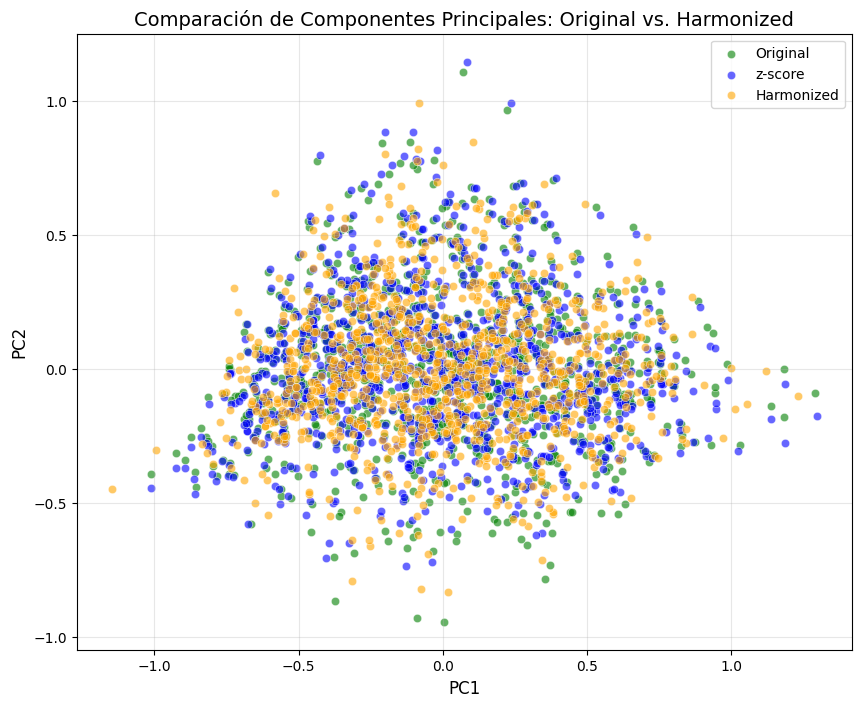

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un gráfico comparativo de PC1 vs PC2
plt.figure(figsize=(10, 8))

# Datos originales
sns.scatterplot(
    x=df_unharmonized_gamma40['pca-one'],
    y=df_unharmonized_gamma40['pca-two'],
    color='green',
    alpha=0.6,
    label='Original'
)

# Datos zscore
sns.scatterplot(
    x=df_zscore_gamma40['pca-one'],
    y=df_zscore_gamma40['pca-two'],
    color='blue',
    alpha=0.6,
    label='z-score'
)

# Datos armonizados
sns.scatterplot(
    x=combat_df_gamma40_wosex['harmonized-pca-one'],
    y=combat_df_gamma40_wosex['harmonized-pca-two'],
    color='orange',
    alpha=0.6,
    label='Harmonized'
)

# Añadir títulos y etiquetas
plt.title('Comparación de Componentes Principales: Original vs. Harmonized', fontsize=14)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()


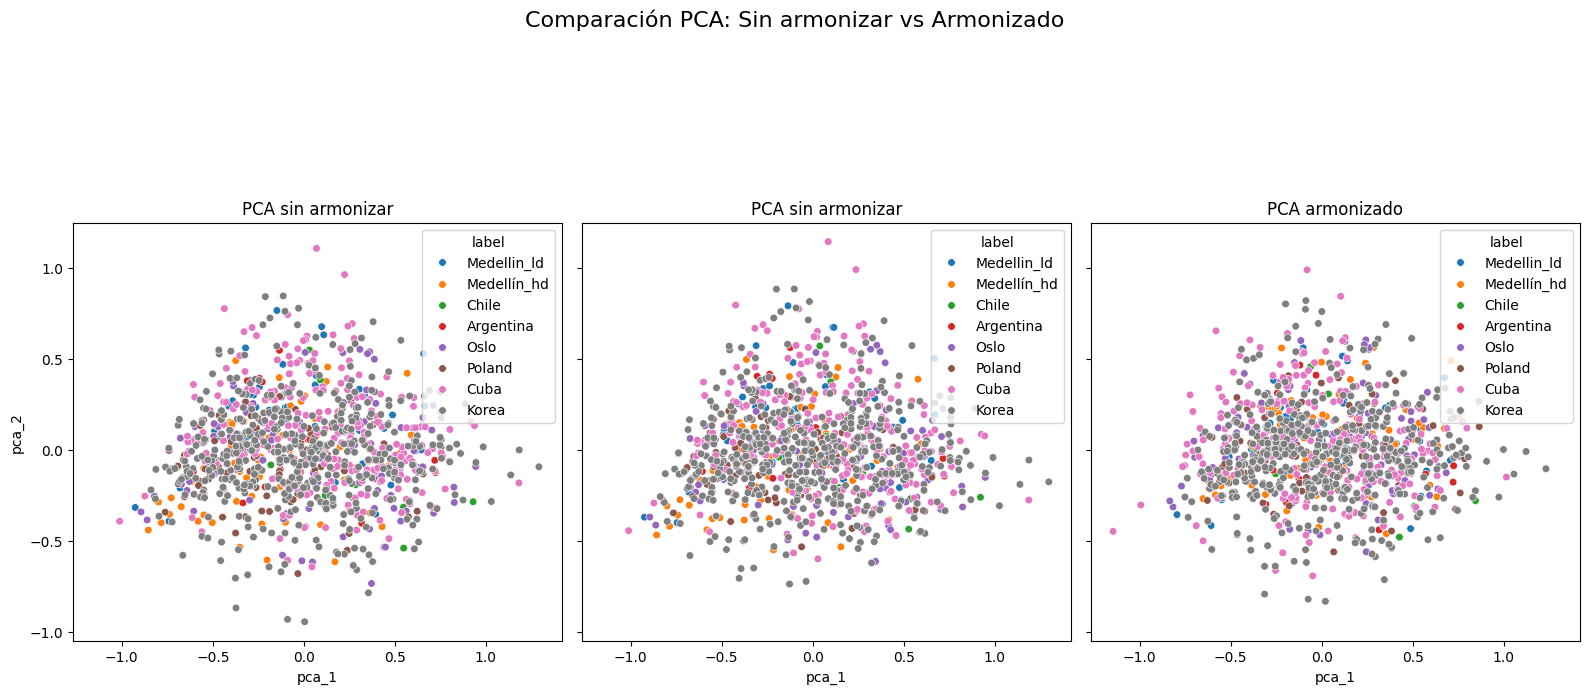

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import pairwise_distances

pca_raw_unharmonized = pd.DataFrame({
    'pca_1': df_unharmonized_gamma40['pca-one'],
    'pca_2': df_unharmonized_gamma40['pca-two'],
    'label': df_unharmonized_gamma40['Site']
})

pca_raw_df = pd.DataFrame({
    'pca_1': df_zscore_gamma40['pca-one'],
    'pca_2': df_zscore_gamma40['pca-two'],
    'label': le_center.inverse_transform(df_zscore_gamma40['Site'])
})

pca_harmonized_df = pd.DataFrame({
    'pca_1': combat_df_gamma40_wosex['harmonized-pca-one'],
    'pca_2': combat_df_gamma40_wosex['harmonized-pca-two'],
    'label': le_center.inverse_transform(combat_df_gamma40_wosex['Site'])
})

# Calcular la distancia euclidiana promedio
unharmonized_coords = pca_raw_unharmonized[['pca_1', 'pca_2']].values
raw_coords = pca_raw_df[['pca_1', 'pca_2']].values
harmonized_coords = pca_harmonized_df[['pca_1', 'pca_2']].values

# Crear subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 8), sharex=True, sharey=True)

# Gráfico de PCA sin armonizar
sns.scatterplot(
    x='pca_1', y='pca_2', hue='label', data=pca_raw_unharmonized, ax=axes[0], s=30, palette='tab10'
)
axes[0].set_title('PCA sin armonizar')
axes[0].set_aspect('equal')

#Grafico de PCA Z-score
sns.scatterplot(
    x='pca_1', y='pca_2', hue='label', data=pca_raw_df, ax=axes[1], s=30, palette='tab10'
)
axes[1].set_title('PCA sin armonizar')
axes[1].set_aspect('equal')

# Gráfico de PCA armonizado
sns.scatterplot(
    x='pca_1', y='pca_2', hue='label', data=pca_harmonized_df, ax=axes[2], s=30, palette='tab10'
)
axes[2].set_title('PCA armonizado')
axes[2].set_aspect('equal')


plt.suptitle('Comparación PCA: Sin armonizar vs Armonizado', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


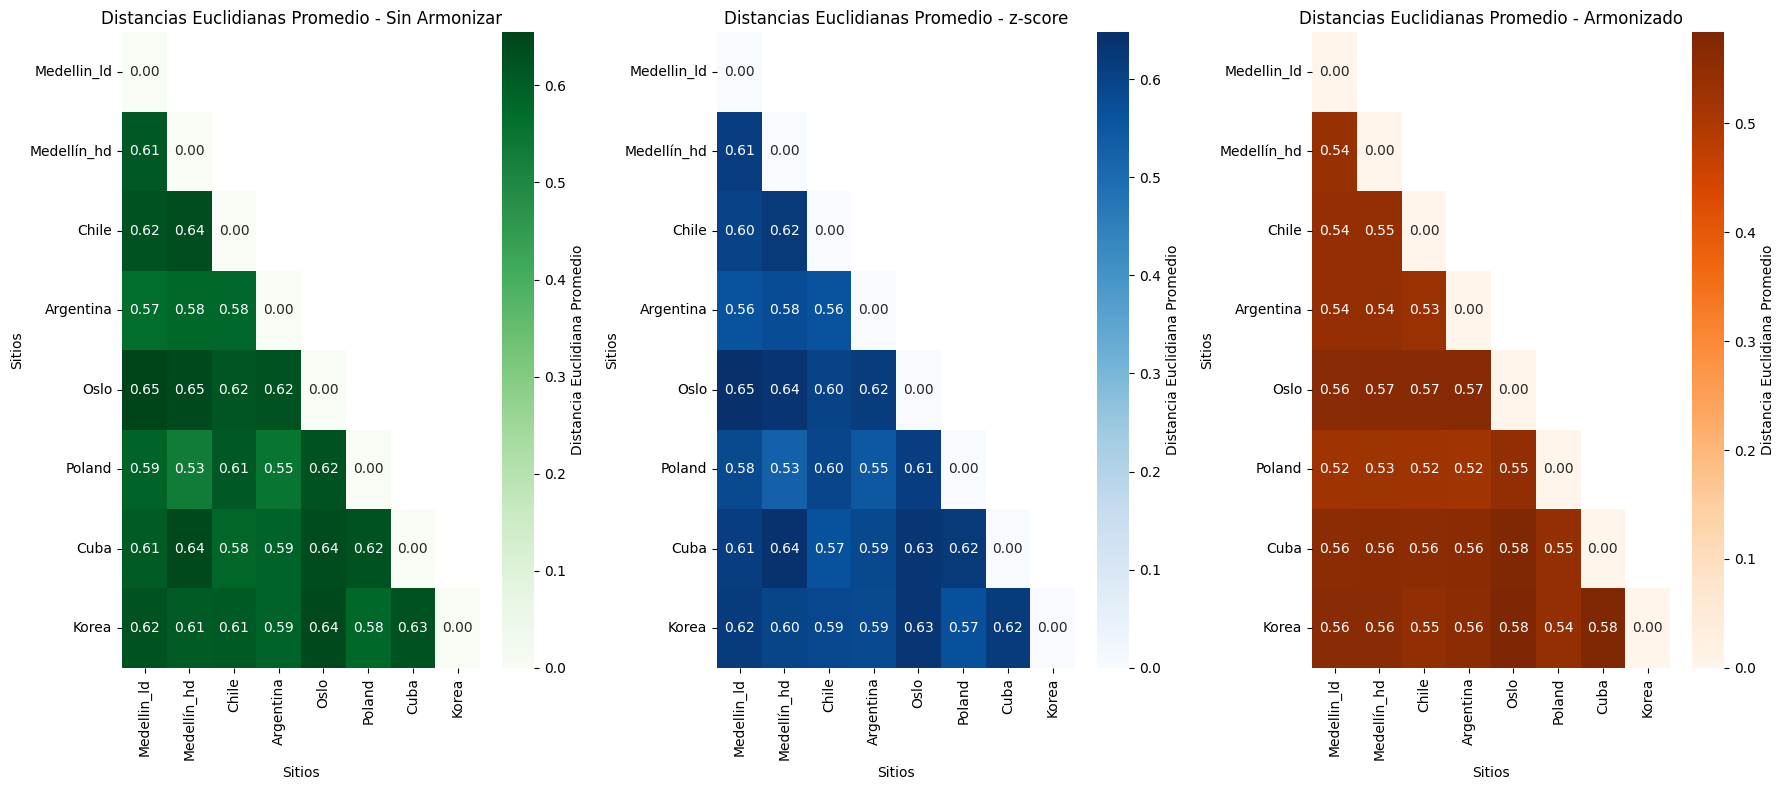

In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Obtener etiquetas únicas de los sitios
sites = df_zscore_gamma40['Site'].unique()
site_labels = le_center.inverse_transform(sites)

# Crear DataFrames para PCA por sitio
unharmonized_coords_by_site = {
    site: pca_raw_unharmonized[pca_raw_unharmonized['label'] == le_center.inverse_transform([site])[0]][['pca_1', 'pca_2']].values
    for site in sites
}


raw_coords_by_site = {
    site: pca_raw_df[pca_raw_df['label'] == le_center.inverse_transform([site])[0]][['pca_1', 'pca_2']].values
    for site in sites
}

harmonized_coords_by_site = {
    site: pca_harmonized_df[pca_harmonized_df['label'] == le_center.inverse_transform([site])[0]][['pca_1', 'pca_2']].values
    for site in sites
}

# Función para calcular la distancia euclidiana promedio entre sitios
def compute_mean_distances(coords_by_site):
    n_sites = len(sites)
    distance_matrix = np.zeros((n_sites, n_sites))
    
    for i, site_i in enumerate(sites):
        for j, site_j in enumerate(sites):
            if i != j:
                distances = pairwise_distances(coords_by_site[site_i], coords_by_site[site_j], metric='euclidean')
                distance_matrix[i, j] = distances.mean()
            else:
                distance_matrix[i, j] = 0  # Distancia con uno mismo es 0
    
    return distance_matrix

# Función para crear la máscara de la parte inferior de la diagonal
def mask_lower_triangle(matrix):
    mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)
    return mask

# Calcular matrices de distancia promedio
unharmonized_distance_matrix = compute_mean_distances(unharmonized_coords_by_site)
raw_distance_matrix = compute_mean_distances(raw_coords_by_site)
harmonized_distance_matrix = compute_mean_distances(harmonized_coords_by_site)

# Crear DataFrames para graficar
unharmonized_distance_df = pd.DataFrame(unharmonized_distance_matrix, index=site_labels, columns=site_labels)
raw_distance_df = pd.DataFrame(raw_distance_matrix, index=site_labels, columns=site_labels)
harmonized_distance_df = pd.DataFrame(harmonized_distance_matrix, index=site_labels, columns=site_labels)

# Crear la máscara para enmascarar la parte inferior de la diagonal
unharmonized_mask = mask_lower_triangle(unharmonized_distance_df.values)
raw_mask = mask_lower_triangle(raw_distance_df.values)
harmonized_mask = mask_lower_triangle(harmonized_distance_df.values)

# Graficar matrices como mapas de calor (solo un lado de la diagonal)
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

sns.heatmap(
    unharmonized_distance_df, annot=True, fmt=".2f", cmap="Greens", ax=axes[0],
    mask=unharmonized_mask, cbar_kws={'label': 'Distancia Euclidiana Promedio'}
)
axes[0].set_title("Distancias Euclidianas Promedio - Sin Armonizar")
axes[0].set_xlabel("Sitios")
axes[0].set_ylabel("Sitios")

sns.heatmap(
    raw_distance_df, annot=True, fmt=".2f", cmap="Blues", ax=axes[1],
    mask=raw_mask, cbar_kws={'label': 'Distancia Euclidiana Promedio'}
)
axes[1].set_title("Distancias Euclidianas Promedio - z-score")
axes[1].set_xlabel("Sitios")
axes[1].set_ylabel("Sitios")

sns.heatmap(
    harmonized_distance_df, annot=True, fmt=".2f", cmap="Oranges", ax=axes[2],
    mask=harmonized_mask, cbar_kws={'label': 'Distancia Euclidiana Promedio'}
)
axes[2].set_title("Distancias Euclidianas Promedio - Armonizado")
axes[2].set_xlabel("Sitios")
axes[2].set_ylabel("Sitios")

plt.tight_layout()
plt.show()


## Validación de supuestos

In [48]:
from pingouin import ancova, homoscedasticity
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kstest, levene

# Crear tabla para almacenar resultados de los supuestos
supuestos = pd.DataFrame(columns=["Feature",'ks_stat_unharmonized','ks_pval_unharmonized','ks_unharmonized','levene_stat_unharmonized','levene_pval_unharmonized','Levene_unharmonized','ks_stat_zscore','ks_pval_zscore','ks_zscore','levene_stat_zscore','levene_pval_zscore','Levene_zscore','ks_Harmonized','ks_stat_Harmonized','ks_pval_Harmonized','levene_stat_Harmonized','levene_pval_Harmonized','levene_Harmonized'])

# Realizar ANCOVA y validar supuestos para cada variable dependiente
for feature in features_rpower:
    data_unharmonize = df_unharmonized_gamma40[[feature, 'age', 'Site']].dropna()
    data_zscore = df_zscore_gamma40[[feature, 'age', 'Site']].dropna()
    data_harmonize = combat_df_gamma40_wosex[[feature, 'age', 'Site']].dropna()
    y_unharmonize = data_unharmonize[feature]
    y_zscore = data_zscore[feature]
    y_harmonize = data_harmonize[feature]
    
    # 1. Normalidad con Kolmogorov-Smirnov
    ks_stat_unharmonized, ks_pval_unharmonized = kstest(y_unharmonize, 'norm', args=(y.mean(), y.std()))
    Norm_unharmonized = "Normal" if ks_pval_unharmonized >= 0.05 else "No normal"
    
    ks_stat, ks_pval = kstest(y_zscore, 'norm', args=(y.mean(), y.std()))
    Norm_zscore = "Normal" if ks_pval >= 0.05 else "No normal"
    
    ks_stat_harmonized, ks_pval_harmonized = kstest(y_harmonize, 'norm', args=(y.mean(), y.std()))
    Norm_Harmonized = "Normal" if ks_pval >= 0.05 else "No normal"
    
    # 2. Homogeneidad de varianzas con Levene
    grouped_data_unharmonize = [data_unharmonize[data_unharmonize['Site'] == site][feature] for site in data_unharmonize['Site'].unique()]
    levene_stat_unharmonized, levene_pval_unharmonized = levene(*grouped_data_unharmonize)
    Hom_unharmonized = "Homocedástico" if levene_pval_unharmonized >= 0.05 else "Heterocedástico"
    
    grouped_data_zscore = [data_zscore[data_zscore['Site'] == site][feature] for site in data_zscore['Site'].unique()]
    levene_stat, levene_pval = levene(*grouped_data_zscore)
    Hom_zscore = "Homocedástico" if levene_pval >= 0.05 else "Heterocedástico"
    
    grouped_data_harmonize = [data_harmonize[data_harmonize['Site'] == site][feature] for site in data_harmonize['Site'].unique()]
    levene_stat_harmonized, levene_pval_harmonized = levene(*grouped_data_harmonize)
    Hom_Harmonized = "Homocedástico" if levene_pval_harmonized >= 0.05 else "Heterocedástico"

    
    # Guardar resultados en la tabla de supuestos
    supuestos = pd.concat([
        supuestos, 
        pd.DataFrame({
            "Feature": [feature],
            "ks_stat_unharmonized": [ks_stat_unharmonized],
            "ks_pval_unharmonized": [ks_pval_unharmonized],
            "ks_unharmonized": [Norm_unharmonized],
            "levene_stat_unharmonized": [levene_stat_unharmonized],
            "levene_pval_unharmonized": [levene_pval_unharmonized],
            "Levene_unharmonized": [Hom_unharmonized],
            "ks_stat_zscore": [ks_stat],
            "ks_pval_zscore": [ks_pval],
            "ks_zscore": [Norm_zscore],
            "levene_stat_zscore": [levene_stat],
            "levene_pval_zscore": [levene_pval],
            "Levene_zscore": [Hom_zscore],
            "ks_Harmonized": [Norm_Harmonized],
            "ks_stat_Harmonized": [ks_stat_harmonized],
            "ks_pval_Harmonized": [ks_pval_harmonized],
            "levene_stat_Harmonized": [levene_stat_harmonized],
            "levene_pval_Harmonized": [levene_pval_harmonized],
            "levene_Harmonized": [Hom_Harmonized]
        })
    ], ignore_index=True)

supuestos.to_excel(r'D:\MulticentersEEG\Features_2_normativeModel\gamma_40\val_supuestos_neurocombat_gamma40_wosex.xlsx', index=False)


C:\Users\Luisa\AppData\Local\Temp\ipykernel_9576\2616999673.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  supuestos = pd.concat([


# Get the power - With Gamma 45 Hz

### Format long

In [2]:
# format Long
power_zscore_cl_long = pd.read_feather(r"F:\EEG_MULTICENTER\BrainLat\CL_BIDS\derivatives\power_Chile_rs_zscore_long.feather")
power_zscore_ar_long = pd.read_feather(r"F:\EEG_MULTICENTER\BrainLat\AR_BIDS\derivatives\power_Argentina_rs_zscore_long.feather")
power_zscore_srm_long = pd.read_feather(r"F:\EEG_MULTICENTER\SRM\derivatives\power_Oslo_resteyesc_zscore_long.feather")

power_zscore_bio_long = pd.read_feather(r"F:\EEG_MULTICENTER\BIOMARCADORES\derivatives\power_Medellín hd_CE_zscore_long.feather")
power_zscore_bio_ctr_long = power_zscore_bio_long[(power_zscore_bio_long['group'] == 'CTR') | (power_zscore_bio_long['group'] == 'G2')].reset_index(drop=True)
power_zscore_bio_dta_long = power_zscore_bio_long[(power_zscore_bio_long['group'] == 'DTA')].reset_index(drop=True)
power_zscore_bio_mci_long = power_zscore_bio_long[(power_zscore_bio_long['group'] == 'DCL') | (power_zscore_bio_long['group'] == 'G1')].reset_index(drop=True)

power_zscore_por_long = pd.read_feather(r"F:\EEG_MULTICENTER\BIDS_PORTABLES_CODIFICADO\derivatives\power_Medellin_ld_CE_zscore_long.feather") 
power_zscore_por_ctr_long = power_zscore_por_long[(power_zscore_por_long['group'] == 'CTR') | (power_zscore_por_long['group'] == 'GU')].reset_index(drop=True)
power_zscore_por_mci_long = power_zscore_por_long[(power_zscore_por_long['group'] == 'DCL')].reset_index(drop=True)


power_zscore_poland_long = pd.read_feather(r"F:\EEG_MULTICENTER\Polonia\derivatives\power_Poland_rest_zscore_long.feather")
power_zscore_chmbp_long = pd.read_feather(r"F:\EEG_MULTICENTER\CHMP\derivatives\power_Cuba_protmap_zscore_long.feather")



In [3]:
# Datos usando columnas
print('Subjects CL: ',len(power_zscore_cl_long.subject.unique()))
print('Subjects AR:',len(power_zscore_ar_long.subject.unique()))
print('Subjects SRM: ',len(power_zscore_srm_long.subject.unique()))
print('Subjects BIO CTR',len(power_zscore_bio_ctr_long.subject.unique()))
print('Subjects BIO DTA',len(power_zscore_bio_dta_long.subject.unique()))
print('Subjects BIO MCI',len(power_zscore_bio_mci_long.subject.unique()))
print('Subjects POR CTR',len(power_zscore_por_ctr_long.subject.unique()))
print('Subjects POR MCI',len(power_zscore_por_mci_long.subject.unique()))
print('Subjects CHMBP',len(power_zscore_chmbp_long.subject.unique()))
print('Subjects POLAND',len(power_zscore_poland_long.subject.unique()))

TOTAL_CTR =len(power_zscore_cl_long.subject.unique())+len(power_zscore_ar_long.subject.unique())+len(power_zscore_srm_long.subject.unique())+len(power_zscore_bio_ctr_long.subject.unique())+len(power_zscore_por_ctr_long.subject.unique())+len(power_zscore_chmbp_long.subject.unique())+len(power_zscore_poland_long.subject.unique())
print('TOTAL CONTROLES:',TOTAL_CTR)

Subjects CL:  13
Subjects AR: 19
Subjects SRM:  111
Subjects BIO CTR 72
Subjects BIO DTA 8
Subjects BIO MCI 40
Subjects POR CTR 50
Subjects POR MCI 7
Subjects CHMBP 247
Subjects POLAND 77
TOTAL CONTROLES: 589


### format columns

In [24]:
power_zscore_cl = pd.read_feather(r"F:\EEG_MULTICENTER\BrainLat\CL_BIDS\derivatives\power_Chile_rs_zscore_columns.feather")
power_zscore_cl.drop(['education','laterality','diagnosis'],inplace=True,axis=1)
power_zscore_cl.dropna(inplace=True)

power_zscore_ar= pd.read_feather(r"F:\EEG_MULTICENTER\BrainLat\AR_BIDS\derivatives\power_Argentina_rs_zscore_columns.feather")
power_zscore_ar.drop(['education','laterality','diagnosis'],inplace=True,axis=1)
power_zscore_ar.dropna(inplace=True)

power_zscore_srm = pd.read_feather(r"F:\EEG_MULTICENTER\SRM\derivatives\power_Oslo_resteyesc_zscore_columns.feather")
power_zscore_srm.drop(['ravlt_1', 'ravlt_5', 'ravlt_tot', 'ravlt_imm',
       'ravlt_del', 'ravlt_rec', 'ravlt_fp', 'ds_forw', 'ds_back', 'ds_seq',
       'ds_tot', 'tmt_2', 'tmt_3', 'tmt_4', 'cw_1', 'cw_2', 'cw_3', 'cw_4',
       'vf_1', 'vf_2', 'vf_3'],inplace=True,axis=1)

power_zscore_bio = pd.read_feather(r"F:\EEG_MULTICENTER\BIOMARCADORES\derivatives\power_Medellín hd_CE_zscore_columns.feather")
power_zscore_bio=power_zscore_bio[power_zscore_bio.visit == 'V0'].reset_index(drop=True)
power_zscore_bio.drop(['education', 'MM_total', 'FAS_F', 'FAS_A', 'FAS_S','visit'],inplace=True,axis=1)
power_zscore_bio_ctr = power_zscore_bio[(power_zscore_bio['group'] == 'CTR') | (power_zscore_bio['group'] == 'G2')].reset_index(drop=True)
power_zscore_bio_ctr.dropna(inplace=True)
power_zscore_bio_dta = power_zscore_bio[(power_zscore_bio['group'] == 'DTA')].reset_index(drop=True)
power_zscore_bio_dta.dropna(inplace=True)
power_zscore_bio_mci = power_zscore_bio[(power_zscore_bio['group'] == 'DCL') | (power_zscore_bio['group'] == 'G1')].reset_index(drop=True)
power_zscore_bio_mci.dropna(inplace=True)

power_zscore_por = pd.read_feather(r"F:\EEG_MULTICENTER\BIDS_PORTABLES_CODIFICADO\derivatives\power_Medellin_ld_CE_zscore_columns.feather") 
power_zscore_por.drop(['Escolaridad','MMSE_total'],inplace=True,axis=1)
power_zscore_por_ctr = power_zscore_por[(power_zscore_por['group'] == 'CTR') | (power_zscore_por['group'] == 'GU')].reset_index(drop=True)
power_zscore_por_ctr.dropna(inplace=True)
power_zscore_por_mci = power_zscore_por[(power_zscore_por['group'] == 'DCL')].reset_index(drop=True)
power_zscore_por_mci.dropna(inplace=True)

# Entender porque no hace el merge con los demograficos de la de polonia desde la otra función
power_zscore_poland = pd.read_feather(r"F:\EEG_MULTICENTER\Polonia\derivatives\power_Poland_rest_zscore_columns.feather")
power_zscore_poland.drop(['education'],inplace=True,axis=1)
power_zscore_poland.dropna(inplace=True)

# Entender porque no hace el merge con los demograficos de la cubana desde la otra función
power_zscore_chmbp = pd.read_feather(r"F:\EEG_MULTICENTER\CHMP\derivatives\power_Cuba_protmap_zscore_columns.feather")
# data_demographics = pd.read_excel(r"F:\EEG_MULTICENTER\demographic\dem_CHBMP.xlsx")
# power_zscore_chmbp = pd.merge(power_zscore_chmbp, data_demographics, on=['subject', 'group'], how='outer')
power_zscore_chmbp.drop(['Weight lb', 'Education Level '],inplace=True,axis=1)
power_zscore_chmbp.dropna(inplace=True)

In [25]:
# Datos usando columnas
print('Subjects CL: ',len(power_zscore_cl.subject.unique()))
print('Subjects AR:',len(power_zscore_ar.subject.unique()))
print('Subjects SRM: ',len(power_zscore_srm.subject.unique()))
print('Subjects BIO CTR',len(power_zscore_bio_ctr.subject.unique()))
print('Subjects BIO DTA',len(power_zscore_bio_dta.subject.unique()))
print('Subjects BIO MCI',len(power_zscore_bio_mci.subject.unique()))
print('Subjects POR CTR',len(power_zscore_por_ctr.subject.unique()))
print('Subjects POR MCI',len(power_zscore_por_mci.subject.unique()))
print('Subjects CHMBP',len(power_zscore_chmbp.subject.unique()))
print('Subjects POLAND',len(power_zscore_poland.subject.unique()))

TOTAL_CTR =len(power_zscore_cl.subject.unique())+len(power_zscore_ar.subject.unique())+len(power_zscore_srm.subject.unique())+len(power_zscore_bio_ctr.subject.unique())+len(power_zscore_por_ctr.subject.unique())+len(power_zscore_chmbp.subject.unique())+len(power_zscore_poland.subject.unique())
print('TOTAL CONTROLES:',TOTAL_CTR)

Subjects CL:  13
Subjects AR: 19
Subjects SRM:  111
Subjects BIO CTR 65
Subjects BIO DTA 0
Subjects BIO MCI 39
Subjects POR CTR 50
Subjects POR MCI 7
Subjects CHMBP 247
Subjects POLAND 77
TOTAL CONTROLES: 582


In [26]:
data_columns= pd.concat((power_zscore_por_ctr,power_zscore_bio_ctr,power_zscore_cl,power_zscore_ar,power_zscore_srm,power_zscore_poland,power_zscore_chmbp))
data_columns.drop(['site'],inplace=True,axis=1)

In [11]:
data_columns

,subject,Task,group,C3_Alpha-1,C3_Alpha-2,C3_Beta1,C3_Beta2,C3_Beta3,C3_Delta,C3_Gamma,...,P8_Beta3,P8_Delta,P8_Gamma,P8_Theta,center_x,sex,age,center_y,center,Site
0,sub-CTR001,CE,CTR,0.114351,0.096755,0.171349,0.048777,0.148856,0.272557,0.060055,...,0.105545,0.258643,0.084873,0.078113,Medellin_ld,F,42.0,Medellin_ld,NaN,NaN
1,sub-CTR002,CE,CTR,0.297281,0.106526,0.078850,0.031553,0.068461,0.218527,0.093268,...,0.131544,0.171758,0.200664,0.072224,Medellin_ld,M,31.0,Medellin_ld,NaN,NaN
2,sub-CTR003,CE,CTR,0.244285,0.057172,0.129424,0.038386,0.073140,0.182645,0.076252,...,0.069661,0.161901,0.054667,0.199921,Medellin_ld,M,59.0,Medellin_ld,NaN,NaN
3,sub-CTR004,CE,CTR,0.100884,0.066598,0.158508,0.050022,0.090721,0.321339,0.084255,...,0.096417,0.253529,0.106831,0.123822,Medellin_ld,F,68.0,Medellin_ld,NaN,NaN
4,sub-CTR005,CE,CTR,0.130255,0.153701,0.259183,0.058222,0.067896,0.229474,0.032611,...,0.064449,0.235936,0.054756,0.066283,Medellin_ld,F,59.0,Medellin_ld,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,sub-CBM00280,protmap,HC,0.309928,0.063219,0.053903,0.017777,0.035454,0.277773,0.014852,...,0.034174,0.324757,0.014801,0.262671,NaN,M,19.0,NaN,Cuba,Cuba
243,sub-CBM00281,protmap,HC,0.271320,0.178081,0.124271,0.035579,0.055392,0.151610,0.017925,...,0.052017,0.115382,0.020044,0.143974,NaN,M,44.0,NaN,Cuba,Cuba
244,sub-CBM00282,protmap,HC,0.238631,0.127525,0.053970,0.017195,0.034762,0.282392,0.017991,...,0.039330,0.231223,0.020675,0.260281,NaN,M,25.0,NaN,Cuba,Cuba
245,sub-CBM00283,protmap,HC,0.206718,0.148573,0.094311,0.024422,0.050979,0.337994,0.032979,...,0.054743,0.258213,0.037984,0.097831,NaN,F,31.0,NaN,Cuba,Cuba


Data_long_zscore

In [12]:
data_long_zscore = pd.concat((power_zscore_cl_long, power_zscore_ar_long, power_zscore_chmbp_long,power_zscore_por_ctr_long,power_zscore_bio_ctr_long ,power_zscore_srm_long,power_zscore_poland_long))
print(len(data_long_zscore.subject.unique()))

570


C:\Users\Luisa\AppData\Local\Temp\ipykernel_14660\3011765657.py:3: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  boxplot = sns.boxplot(x='Band', y='power', hue='center', data=data_long_zscore, palette=vivid_colors)


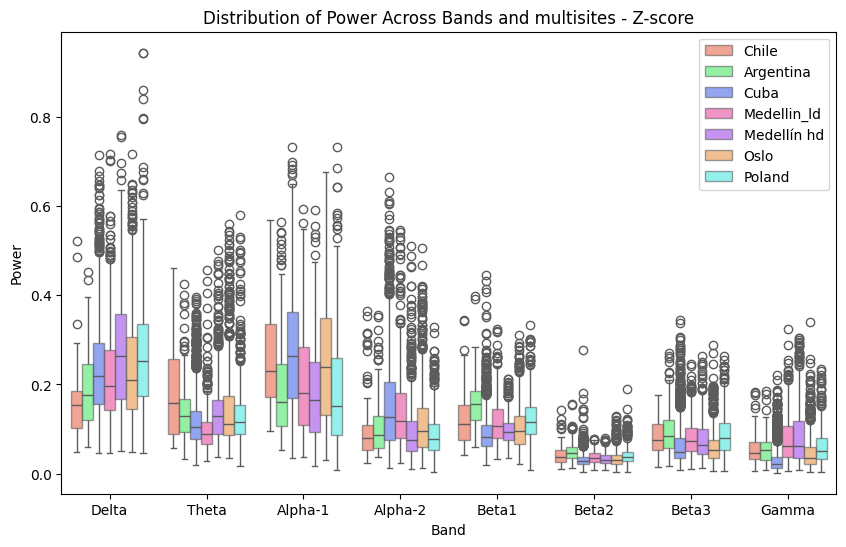

In [13]:
plt.figure(figsize=(10, 6))
vivid_colors = ['#FF5733', '#33FF57', '#3357FF', '#FF33A1', '#A133FF', '#FF9633', '#33FFF6','#FFC733']
boxplot = sns.boxplot(x='Band', y='power', hue='center', data=data_long_zscore, palette=vivid_colors)

# Ajustar la opacidad de las cajas
for patch in boxplot.patches:
    patch.set_alpha(0.6)  # Ajusta la opacidad aquí

# Ajustar la opacidad de las etiquetas en la leyenda
handles, labels = boxplot.get_legend_handles_labels()
for handle in handles:
    handle.set_alpha(0.6)  # Ajusta la opacidad de los colores de la leyenda

plt.xlabel('Band')
plt.ylabel('Power')
_ = plt.title('Distribution of Power Across Bands and multisites - Z-score')
plt.legend(handles, labels)  # Reagregar la leyenda con la opacidad ajustada


C:\Users\Luisa\AppData\Local\Temp\ipykernel_14660\311547139.py:2: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  sns.kdeplot(data=data_long_zscore, x='power', hue='center', fill=True, palette=vivid_colors, alpha=0.5)


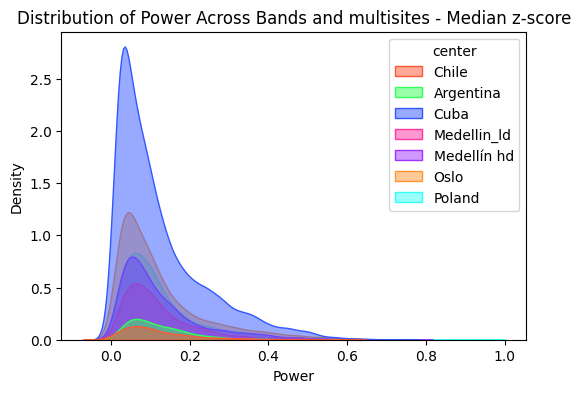

In [15]:
plt.figure(figsize=(6, 4))
sns.kdeplot(data=data_long_zscore, x='power', hue='center', fill=True, palette=vivid_colors, alpha=0.5)
plt.xlabel('Power')
plt.ylabel('Density')
_ = plt.title('Distribution of Power Across Bands and multisites - Median z-score')

C:\Users\Luisa\AppData\Local\Temp\ipykernel_14660\1121063688.py:9: UserWarning: The palette list has more values (7) than needed (2), which may not be intended.
  sns.kdeplot(data=data_columns, x='age',hue='sex', fill=True, common_norm=False, palette=mi_paleta, ax=ax1)
C:\Users\Luisa\AppData\Local\Temp\ipykernel_14660\1121063688.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='sex', y='age', data=data_columns, palette=mi_paleta, ax=ax2)
C:\Users\Luisa\AppData\Local\Temp\ipykernel_14660\1121063688.py:17: UserWarning: The palette list has more values (7) than needed (2), which may not be intended.
  sns.swarmplot(x='sex', y='age', data=data_columns, palette=mi_paleta, ax=ax2)


Text(42.097222222222214, 0.5, 'Age')

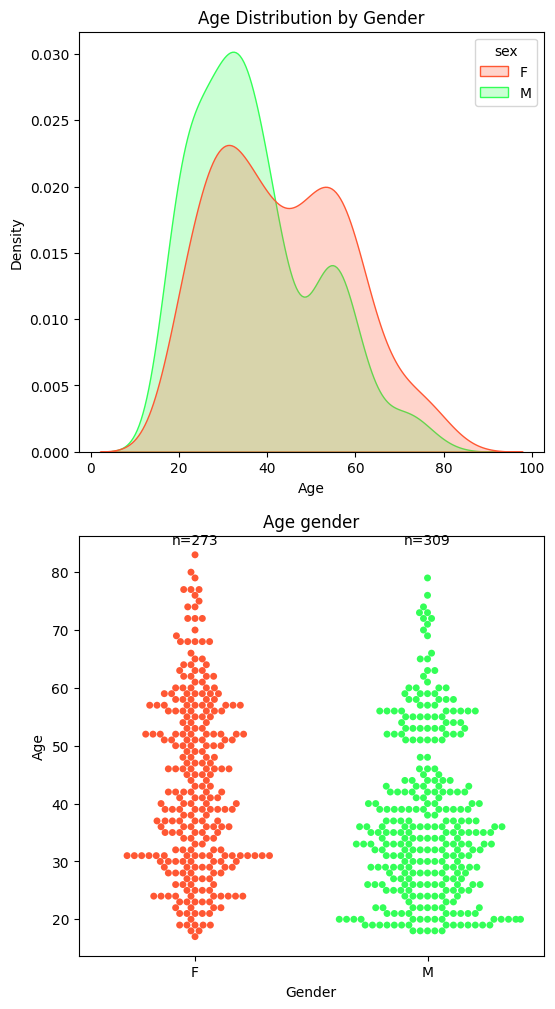

In [16]:
plt.figure(figsize=(6, 12))
vivid_colors = ['#FF5733', '#33FF57', '#3357FF', '#FF33A1', '#A133FF', '#FF9633', '#33FFF6']
colores_personalizados = vivid_colors

mi_paleta = sns.color_palette(colores_personalizados)
# Gráfico de densidad

ax1 = plt.subplot(2, 1, 1)
sns.kdeplot(data=data_columns, x='age',hue='sex', fill=True, common_norm=False, palette=mi_paleta, ax=ax1)
ax1.set_title('Age Distribution by Gender')
ax1.set_xlabel('Age')
ax1.set_ylabel('Density')


# Swarmplot
ax2 = plt.subplot(2, 1, 2)
sns.swarmplot(x='sex', y='age', data=data_columns, palette=mi_paleta, ax=ax2)
# Añadir etiquetas con el número de sujetos
for i, group in enumerate(data_columns['sex'].unique()):
    count = data_columns[data_columns['sex'] == group].shape[0]
    ax2.text(i, ax2.get_ylim()[1] -2, f'n={count}', ha='center', va='bottom')

ax2.set_title('Age gender')
ax2.set_xlabel('Gender')
ax2.set_ylabel('Age')

In [17]:
feature_names_parietal_occipital = ['O1_Alpha-1', 'O1_Alpha-2', 'O2_Alpha-1',
                'O2_Alpha-2','P7_Alpha-1', 'P7_Alpha-2', 'P8_Alpha-1',
                'P8_Alpha-2']

In [18]:
data_columns

,subject,Task,group,C3_Alpha-1,C3_Alpha-2,C3_Beta1,C3_Beta2,C3_Beta3,C3_Delta,C3_Gamma,...,P8_Beta3,P8_Delta,P8_Gamma,P8_Theta,center_x,sex,age,center_y,center,Site
0,sub-CTR001,CE,CTR,0.114351,0.096755,0.171349,0.048777,0.148856,0.272557,0.060055,...,0.105545,0.258643,0.084873,0.078113,Medellin_ld,F,42.0,Medellin_ld,NaN,NaN
1,sub-CTR002,CE,CTR,0.297281,0.106526,0.078850,0.031553,0.068461,0.218527,0.093268,...,0.131544,0.171758,0.200664,0.072224,Medellin_ld,M,31.0,Medellin_ld,NaN,NaN
2,sub-CTR003,CE,CTR,0.244285,0.057172,0.129424,0.038386,0.073140,0.182645,0.076252,...,0.069661,0.161901,0.054667,0.199921,Medellin_ld,M,59.0,Medellin_ld,NaN,NaN
3,sub-CTR004,CE,CTR,0.100884,0.066598,0.158508,0.050022,0.090721,0.321339,0.084255,...,0.096417,0.253529,0.106831,0.123822,Medellin_ld,F,68.0,Medellin_ld,NaN,NaN
4,sub-CTR005,CE,CTR,0.130255,0.153701,0.259183,0.058222,0.067896,0.229474,0.032611,...,0.064449,0.235936,0.054756,0.066283,Medellin_ld,F,59.0,Medellin_ld,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,sub-CBM00280,protmap,HC,0.309928,0.063219,0.053903,0.017777,0.035454,0.277773,0.014852,...,0.034174,0.324757,0.014801,0.262671,NaN,M,19.0,NaN,Cuba,Cuba
243,sub-CBM00281,protmap,HC,0.271320,0.178081,0.124271,0.035579,0.055392,0.151610,0.017925,...,0.052017,0.115382,0.020044,0.143974,NaN,M,44.0,NaN,Cuba,Cuba
244,sub-CBM00282,protmap,HC,0.238631,0.127525,0.053970,0.017195,0.034762,0.282392,0.017991,...,0.039330,0.231223,0.020675,0.260281,NaN,M,25.0,NaN,Cuba,Cuba
245,sub-CBM00283,protmap,HC,0.206718,0.148573,0.094311,0.024422,0.050979,0.337994,0.032979,...,0.054743,0.258213,0.037984,0.097831,NaN,F,31.0,NaN,Cuba,Cuba


# Harmonize

## Neurocombat

In [ ]:
pip install neurocombat-sklearn

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\flujo_portables\env\Scripts\python.exe -m pip install --upgrade pip' command.


In [97]:
from sklearn.preprocessing import LabelEncoder
le_center = LabelEncoder()
le_center.fit(data_columns['center'])
print(list(le_center.classes_))

le_gender = LabelEncoder()
le_gender.fit(data_columns['sex'])
print(list(le_gender.classes_))

['Argentina', 'Chile', 'Cuba', 'Medellín hd', 'Medellín ld', 'Oslo', 'Poland']
['F', 'M']


In [98]:
from sklearn.preprocessing import LabelEncoder

cols = ['center', 'sex']
le = LabelEncoder()
# Encode labels of multiple columns at once
data_columns[cols] = data_columns[cols].apply(le.fit_transform)

data_columns.head()

,subject,Task,group,C3_Alpha-1,C3_Alpha-2,C3_Beta1,C3_Beta2,C3_Beta3,C3_Delta,C3_Gamma,...,P8_Beta1,P8_Beta2,P8_Beta3,P8_Delta,P8_Gamma,P8_Theta,center,sex,age,Site
0,sub-CTR001,CE,CTR,0.066768,0.063967,0.142042,0.089860,0.232884,0.159720,0.194514,...,0.168219,0.097924,0.225199,0.132719,0.215044,0.038262,4,0,42.0,Medellín_ld
1,sub-CTR002,CE,CTR,0.291954,0.107818,0.079679,0.031788,0.067836,0.222821,0.091100,...,0.104154,0.048233,0.128952,0.175437,0.194633,0.073604,4,1,31.0,Medellín_ld
2,sub-CTR003,CE,CTR,0.244285,0.057172,0.129424,0.038386,0.073140,0.182645,0.076252,...,0.133466,0.036491,0.069661,0.161901,0.054667,0.199921,4,1,59.0,Medellín_ld
3,sub-CTR004,CE,CTR,0.100027,0.066181,0.160039,0.050385,0.091188,0.319098,0.084548,...,0.187689,0.054268,0.097474,0.253622,0.108414,0.124492,4,0,68.0,Medellín_ld
4,sub-CTR005,CE,CTR,0.138114,0.157009,0.276692,0.060997,0.063096,0.205981,0.030704,...,0.185872,0.036172,0.052803,0.190252,0.042292,0.068251,4,0,59.0,Medellín_ld


In [100]:
from neurocombat_sklearn import CombatModel
cb_model = CombatModel()
data =data_columns.iloc[:, 3:-4].to_numpy()
# Fitting model
cb_model.fit(data,
             data_columns[['center']],
             data_columns[['sex']],
             data_columns[['age']])

# Harmonize data over hc group
data_combat = cb_model.transform(data,
                                data_columns[['center']],
                                data_columns[['sex']],
                                data_columns[['age']])

d:\flujo_portables\env\lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
d:\flujo_portables\env\lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [101]:
# Crear DataFrame de data_combat con las columnas adecuadas
data_combat_df = pd.DataFrame(data_combat, columns=data_columns.columns[3:-4])

# Concatenar data_combat_df con las últimas tres columnas de data_columns
data_combat_df = pd.concat([data_combat_df, data_columns.iloc[:, -4:].reset_index(drop=True)], axis=1)

data_combat_df


,C3_Alpha-1,C3_Alpha-2,C3_Beta1,C3_Beta2,C3_Beta3,C3_Delta,C3_Gamma,C3_Theta,C4_Alpha-1,C4_Alpha-2,...,P8_Beta1,P8_Beta2,P8_Beta3,P8_Delta,P8_Gamma,P8_Theta,center,sex,age,Site
0,0.077890,0.071726,0.134057,0.094900,0.222517,0.174418,0.137203,0.055001,0.080306,0.073420,...,0.150317,0.094317,0.195148,0.142377,0.132232,0.048260,4,0,42.0,Medellín_ld
1,0.303086,0.113668,0.074239,0.030178,0.058723,0.233131,0.058263,0.123576,0.293653,0.104795,...,0.087718,0.043058,0.104101,0.181410,0.115769,0.093132,4,1,31.0,Medellín_ld
2,0.255416,0.063736,0.123216,0.036307,0.064140,0.191318,0.050507,0.231453,0.247174,0.073171,...,0.116865,0.030702,0.049233,0.164439,0.032973,0.258870,4,1,59.0,Medellín_ld
3,0.111151,0.072405,0.153339,0.048841,0.082138,0.309370,0.057952,0.146759,0.116852,0.065367,...,0.169913,0.048919,0.075943,0.244215,0.070200,0.157428,4,0,68.0,Medellín_ld
4,0.149241,0.159675,0.260841,0.061321,0.054229,0.211457,0.016535,0.073219,0.134102,0.128470,...,0.167875,0.030237,0.033720,0.190003,0.026117,0.081634,4,0,59.0,Medellín_ld
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,0.281630,0.067525,0.059883,0.019093,0.042206,0.282413,0.025258,0.224990,0.266041,0.062866,...,0.063749,0.018071,0.033052,0.347619,0.020157,0.337764,2,1,19.0,Cuba
567,0.244556,0.165926,0.133379,0.040079,0.062171,0.152824,0.025078,0.161398,0.241572,0.170341,...,0.117170,0.031491,0.050276,0.118845,0.022676,0.165679,2,1,44.0,Cuba
568,0.214236,0.123733,0.059224,0.017518,0.041471,0.287746,0.028493,0.225315,0.214969,0.138300,...,0.070707,0.020480,0.037965,0.244534,0.026620,0.331757,2,1,25.0,Cuba
569,0.182959,0.142982,0.101394,0.024848,0.057743,0.346493,0.047690,0.098458,0.238663,0.177529,...,0.113259,0.025510,0.052603,0.275047,0.046843,0.119189,2,0,31.0,Cuba


In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_columns.iloc[:,3:-4].values)

data_columns['pca-one'] = pca_result[:,0]
data_columns['pca-two'] = pca_result[:,1]

pca = PCA(n_components=2)
harmonized_pca_result = pca.fit_transform(data_combat_df.iloc[:,3:-6].values)

data_combat_df['harmonized-pca-one'] = harmonized_pca_result[:,0]
data_combat_df['harmonized-pca-two'] = harmonized_pca_result[:,1]

In [103]:
data_combat_df

,C3_Alpha-1,C3_Alpha-2,C3_Beta1,C3_Beta2,C3_Beta3,C3_Delta,C3_Gamma,C3_Theta,C4_Alpha-1,C4_Alpha-2,...,P8_Beta3,P8_Delta,P8_Gamma,P8_Theta,center,sex,age,Site,harmonized-pca-one,harmonized-pca-two
0,0.077890,0.071726,0.134057,0.094900,0.222517,0.174418,0.137203,0.055001,0.080306,0.073420,...,0.195148,0.142377,0.132232,0.048260,4,0,42.0,Medellín_ld,0.383032,0.217448
1,0.303086,0.113668,0.074239,0.030178,0.058723,0.233131,0.058263,0.123576,0.293653,0.104795,...,0.104101,0.181410,0.115769,0.093132,4,1,31.0,Medellín_ld,-0.090277,-0.018798
2,0.255416,0.063736,0.123216,0.036307,0.064140,0.191318,0.050507,0.231453,0.247174,0.073171,...,0.049233,0.164439,0.032973,0.258870,4,1,59.0,Medellín_ld,-0.256213,-0.230253
3,0.111151,0.072405,0.153339,0.048841,0.082138,0.309370,0.057952,0.146759,0.116852,0.065367,...,0.075943,0.244215,0.070200,0.157428,4,0,68.0,Medellín_ld,0.370876,-0.152762
4,0.149241,0.159675,0.260841,0.061321,0.054229,0.211457,0.016535,0.073219,0.134102,0.128470,...,0.033720,0.190003,0.026117,0.081634,4,0,59.0,Medellín_ld,0.143718,0.141602
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,0.281630,0.067525,0.059883,0.019093,0.042206,0.282413,0.025258,0.224990,0.266041,0.062866,...,0.033052,0.347619,0.020157,0.337764,2,1,19.0,Cuba,-0.160715,-0.379045
567,0.244556,0.165926,0.133379,0.040079,0.062171,0.152824,0.025078,0.161398,0.241572,0.170341,...,0.050276,0.118845,0.022676,0.165679,2,1,44.0,Cuba,-0.233594,0.249055
568,0.214236,0.123733,0.059224,0.017518,0.041471,0.287746,0.028493,0.225315,0.214969,0.138300,...,0.037965,0.244534,0.026620,0.331757,2,1,25.0,Cuba,-0.034292,-0.250351
569,0.182959,0.142982,0.101394,0.024848,0.057743,0.346493,0.047690,0.098458,0.238663,0.177529,...,0.052603,0.275047,0.046843,0.119189,2,0,31.0,Cuba,0.184389,0.020583


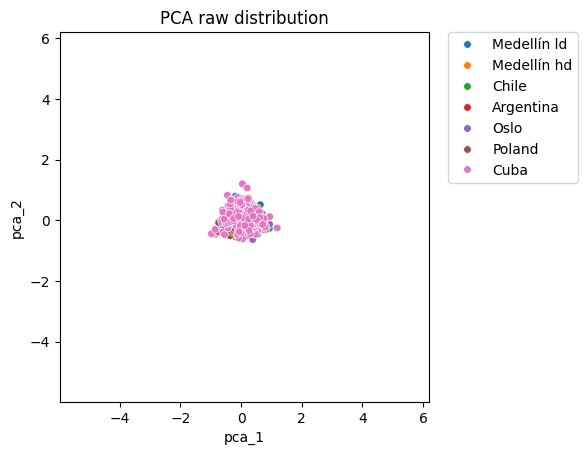

In [109]:
# Crear DataFrame para los resultados de PCA
# Decodificar la columna 'center'
data_columns['center_decoded'] = le_center.inverse_transform(data_combat_df['center'])

# Mostrar los primeros registros para verificar
data_columns[['center', 'center_decoded']].head()
pca_result_df = pd.DataFrame({'pca_1': data_columns['pca-one'], 'pca_2': data_columns['pca-two'], 'label': data_columns['center_decoded']})

# Crear el gráfico de dispersión
fig, ax = plt.subplots(1)
sns.scatterplot(x='pca_1', y='pca_2', hue='label', data=pca_result_df, ax=ax, s=30)
lim = (pca_result_df[['pca_1', 'pca_2']].min().min()-5, pca_result_df[['pca_1', 'pca_2']].max().max()+5)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)
plt.title('PCA raw distribution')
plt.show()

Text(0.5, 1.0, 'NeuroCombat-PCA harmonized distribution')

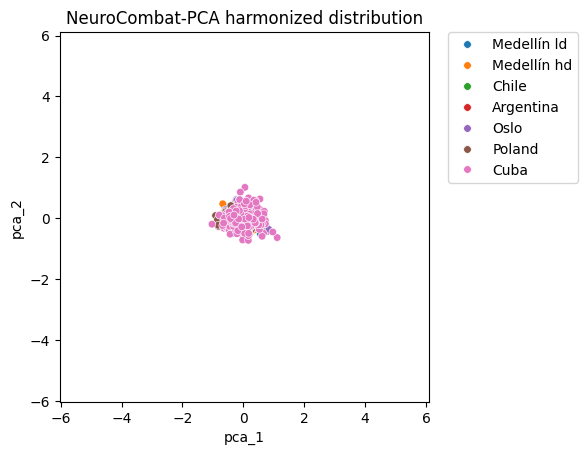

In [108]:
# Decodificar la columna 'center'
data_combat_df['center_decoded'] = le_center.inverse_transform(data_combat_df['center'])

# Mostrar los primeros registros para verificar
data_combat_df[['center', 'center_decoded']].head()

harmonized_pca_result_df = pd.DataFrame({'pca_1': harmonized_pca_result[:,0], 'pca_2': harmonized_pca_result[:,1], 'label': data_combat_df['center_decoded'] })
fig, ax = plt.subplots(1)
sns.scatterplot(x='pca_1', y='pca_2', hue='label', data=harmonized_pca_result_df, ax=ax, s=30)
lim = (harmonized_pca_result.min()-5, harmonized_pca_result.max()+5)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)
plt.title('NeuroCombat-PCA harmonized distribution')

In [115]:
data_combat_df


,C3_Alpha-1,C3_Alpha-2,C3_Beta1,C3_Beta2,C3_Beta3,C3_Delta,C3_Gamma,C3_Theta,C4_Alpha-1,C4_Alpha-2,...,P8_Delta,P8_Gamma,P8_Theta,center,sex,age,Site,harmonized-pca-one,harmonized-pca-two,center_decoded
0,0.077890,0.071726,0.134057,0.094900,0.222517,0.174418,0.137203,0.055001,0.080306,0.073420,...,0.142377,0.132232,0.048260,4,0,42.0,Medellín_ld,0.394863,0.212990,Medellín ld
1,0.303086,0.113668,0.074239,0.030178,0.058723,0.233131,0.058263,0.123576,0.293653,0.104795,...,0.181410,0.115769,0.093132,4,1,31.0,Medellín_ld,-0.083956,-0.008478,Medellín ld
2,0.255416,0.063736,0.123216,0.036307,0.064140,0.191318,0.050507,0.231453,0.247174,0.073171,...,0.164439,0.032973,0.258870,4,1,59.0,Medellín_ld,-0.267356,-0.254420,Medellín ld
3,0.111151,0.072405,0.153339,0.048841,0.082138,0.309370,0.057952,0.146759,0.116852,0.065367,...,0.244215,0.070200,0.157428,4,0,68.0,Medellín_ld,0.367092,-0.169959,Medellín ld
4,0.149241,0.159675,0.260841,0.061321,0.054229,0.211457,0.016535,0.073219,0.134102,0.128470,...,0.190003,0.026117,0.081634,4,0,59.0,Medellín_ld,0.147321,0.145691,Medellín ld
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,0.281630,0.067525,0.059883,0.019093,0.042206,0.282413,0.025258,0.224990,0.266041,0.062866,...,0.347619,0.020157,0.337764,2,1,19.0,Cuba,-0.179221,-0.410261,Cuba
567,0.244556,0.165926,0.133379,0.040079,0.062171,0.152824,0.025078,0.161398,0.241572,0.170341,...,0.118845,0.022676,0.165679,2,1,44.0,Cuba,-0.233863,0.236869,Cuba
568,0.214236,0.123733,0.059224,0.017518,0.041471,0.287746,0.028493,0.225315,0.214969,0.138300,...,0.244534,0.026620,0.331757,2,1,25.0,Cuba,-0.051333,-0.285993,Cuba
569,0.182959,0.142982,0.101394,0.024848,0.057743,0.346493,0.047690,0.098458,0.238663,0.177529,...,0.275047,0.046843,0.119189,2,0,31.0,Cuba,0.185009,0.022154,Cuba


In [ ]:
cols_to_exclude = ['harmonized-pca-one', 'harmonized-pca-two','center', 'Site']  # Ajustar las columnas que realmente existen
df_harmonized_long = pd.melt(data_combat_df.drop(columns=cols_to_exclude), 
                  id_vars=['center_decoded', 'sex', 'age'],  
                  var_name='channel_band', 
                  value_name='power')
# # Separar la columna 'channel_band' en 'channel' y 'band'
df_harmonized_long[['channel', 'Band']] = df_harmonized_long['channel_band'].str.split('_', n=1, expand=True)

# # Eliminar la columna original 'channel_band'
df_harmonized_long = df_harmonized_long.drop(columns='channel_band')
df_harmonized_long

,center_decoded,sex,age,power,channel,Band
0,Medellín ld,0,42.0,0.077890,C3,Alpha-1
1,Medellín ld,1,31.0,0.303086,C3,Alpha-1
2,Medellín ld,1,59.0,0.255416,C3,Alpha-1
3,Medellín ld,0,68.0,0.111151,C3,Alpha-1
4,Medellín ld,0,59.0,0.149241,C3,Alpha-1
...,...,...,...,...,...,...
36539,Cuba,1,19.0,0.337764,P8,Theta
36540,Cuba,1,44.0,0.165679,P8,Theta
36541,Cuba,1,25.0,0.331757,P8,Theta
36542,Cuba,0,31.0,0.119189,P8,Theta


C:\Users\Luisa\AppData\Local\Temp\ipykernel_20292\1294345128.py:7: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  boxplot = sns.boxplot(x='Band', y='power', hue='center_decoded', data=df_harmonized_long, palette=vivid_colors)


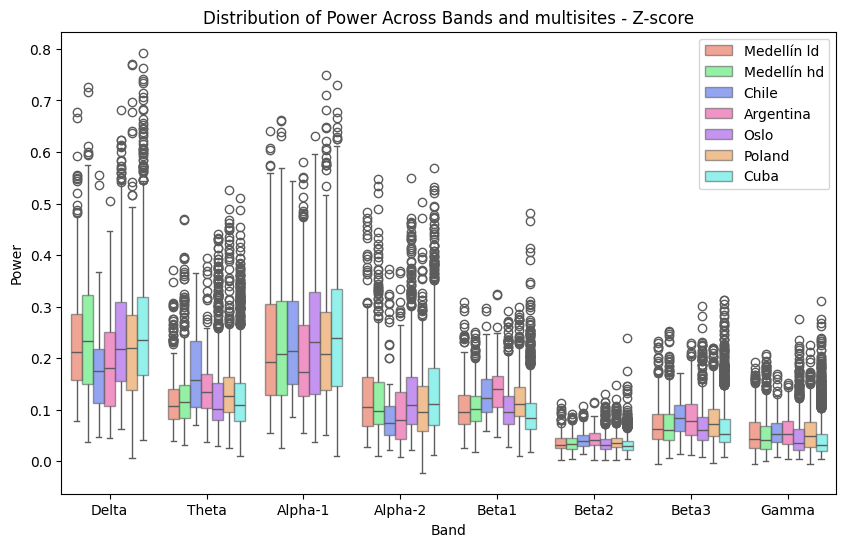

In [147]:
# Organizar las bandas en el orden deseado
band_order = ['Delta', 'Theta', 'Alpha-1', 'Alpha-2', 'Beta1', 'Beta2', 'Beta3', 'Gamma']
df_harmonized_long['Band'] = pd.Categorical(df_harmonized_long['Band'], categories=band_order, ordered=True)

plt.figure(figsize=(10, 6))
vivid_colors = ['#FF5733', '#33FF57', '#3357FF', '#FF33A1', '#A133FF', '#FF9633', '#33FFF6','#FFC733']
boxplot = sns.boxplot(x='Band', y='power', hue='center_decoded', data=df_harmonized_long, palette=vivid_colors)

# Ajustar la opacidad de las cajas
for patch in boxplot.patches:
    patch.set_alpha(0.6)  # Ajusta la opacidad aquí

# Ajustar la opacidad de las etiquetas en la leyenda
handles, labels = boxplot.get_legend_handles_labels()
for handle in handles:
    handle.set_alpha(0.6)  # Ajusta la opacidad de los colores de la leyenda

plt.xlabel('Band')
plt.ylabel('Power')
_ = plt.title('Distribution of Power Across Bands and multisites - Z-score')
plt.legend(handles, labels)  # Reagregar la leyenda con la opacidad ajustada


In [148]:
# Estadísticas descriptivas para el primer conjunto de datos
stats_data_1 = data_long_zscore.groupby(['Band', 'center'])['power'].describe()

# Estadísticas descriptivas para el segundo conjunto de datos
stats_data_2 = df_harmonized_long.groupby(['Band', 'center_decoded'])['power'].describe()

# Mostrar las estadísticas para comparar
print("Estadísticas sin armonizar:\n", stats_data_1)



C:\Users\Luisa\AppData\Local\Temp\ipykernel_20292\2461335373.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_data_2 = df_harmonized_long.groupby(['Band', 'center_decoded'])['power'].describe()


Estadísticas sin armonizar:
                       count      mean       std       min       25%       50%  \
Band    center                                                                  
Alpha-1 Argentina     152.0  0.202061  0.124055  0.052694  0.107818  0.159851   
        Chile         104.0  0.255448  0.111401  0.095495  0.172242  0.229763   
        Cuba         1976.0  0.273458  0.133185  0.036139  0.170040  0.263497   
        Medellín hd   576.0  0.188159  0.111456  0.017250  0.093015  0.164902   
        Medellín ld   312.0  0.203210  0.122039  0.036061  0.104092  0.163223   
        Oslo          888.0  0.252370  0.144381  0.031407  0.130499  0.237947   
        Poland        616.0  0.188637  0.126237  0.009032  0.087577  0.151572   
Alpha-2 Argentina     152.0  0.107126  0.068364  0.036565  0.057079  0.085924   
        Chile         104.0  0.101344  0.076916  0.024309  0.053319  0.080184   
        Cuba         1976.0  0.153966  0.103538  0.013376  0.076520  0.126347   

In [149]:
print("\nEstadísticas armonizando:\n", stats_data_2)


Estadísticas armonizando:
                          count      mean       std       min       25%  \
Band    center_decoded                                                   
Delta   Argentina        152.0  0.190425  0.100704  0.045997  0.107460   
        Chile            104.0  0.174930  0.088187  0.046726  0.112514   
        Cuba            1976.0  0.254678  0.117849  0.042089  0.167962   
        Medellín hd      520.0  0.244162  0.116841  0.037125  0.149748   
        Medellín ld      312.0  0.239316  0.113393  0.078097  0.156742   
        Oslo             888.0  0.244258  0.118187  0.063479  0.155109   
        Poland           616.0  0.219768  0.112588  0.005744  0.137311   
Theta   Argentina        152.0  0.148201  0.072265  0.036825  0.102781   
        Chile            104.0  0.172506  0.078800  0.069470  0.104886   
        Cuba            1976.0  0.124902  0.069466  0.010656  0.077762   
        Medellín hd      520.0  0.129302  0.071036  0.030799  0.083242   
        Me

In [150]:
# Calcular las medias para cada grupo en el primer conjunto de datos
mean_data_1 = data_long_zscore.groupby(['Band', 'center'])['power'].mean()

# Calcular las medias para cada grupo en el segundo conjunto de datos
mean_data_2 = df_harmonized_long.groupby(['Band', 'center_decoded'])['power'].mean()

# Comparar las medias
mean_diff = mean_data_1 - mean_data_2
print("Diferencia de medias entre los dos gráficos:\n", mean_diff)


Diferencia de medias entre los dos gráficos:
 Band     center     center_decoded
Alpha-1  Argentina  Argentina        -0.011965
                    Chile            -0.036881
                    Cuba             -0.048192
                    Medellín hd      -0.031247
                    Medellín ld      -0.028119
                                        ...   
Theta    Poland     Cuba              0.011234
                    Medellín hd       0.006834
                    Medellín ld       0.014505
                    Oslo              0.007712
                    Poland           -0.007719
Name: power, Length: 392, dtype: float64


C:\Users\Luisa\AppData\Local\Temp\ipykernel_20292\2954647600.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_data_2 = df_harmonized_long.groupby(['Band', 'center_decoded'])['power'].mean()


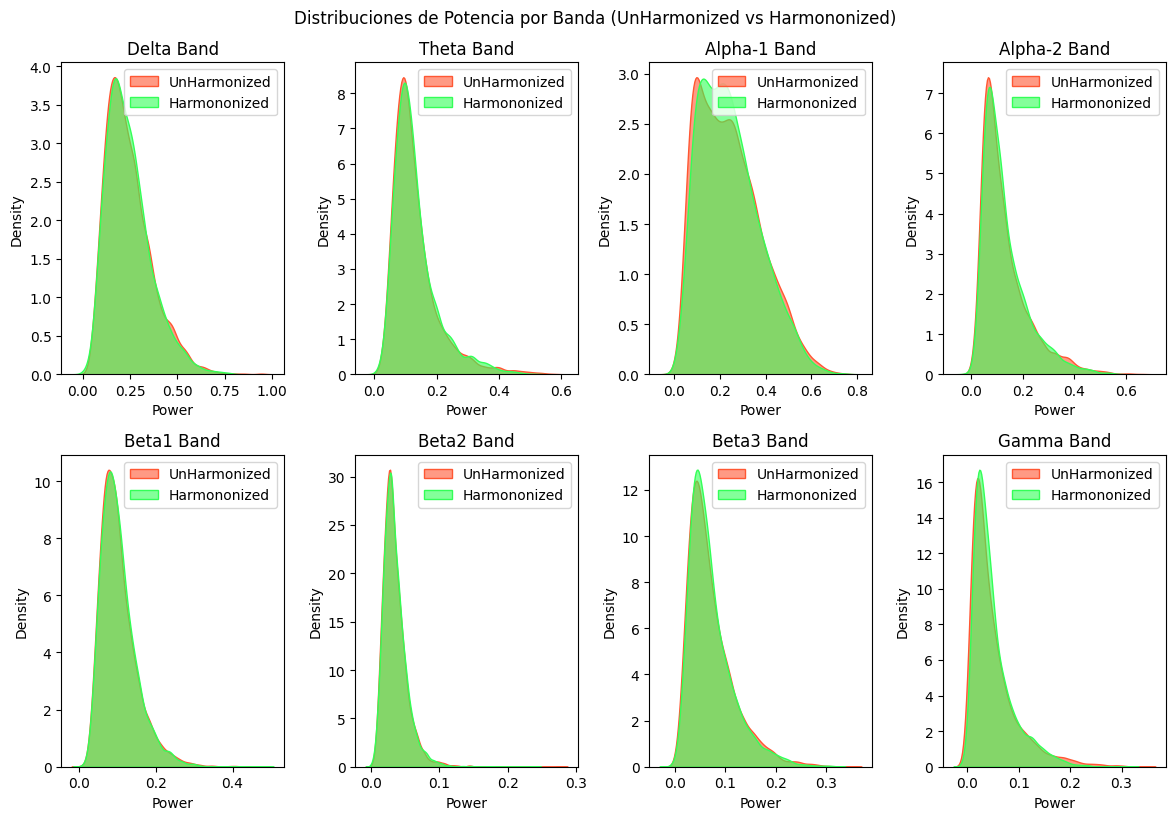

In [152]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear una figura para las gráficas de densidad
plt.figure(figsize=(12, 8))

# Colores para los gráficos
vivid_colors = ['#FF5733', '#33FF57', '#3357FF', '#FF33A1', '#A133FF', '#FF9633', '#33FFF6','#FFC733']

# Graficar para cada banda
for i, band in enumerate(band_order):
    plt.subplot(2, 4, i + 1)  # Crear subplots 2x4 para cada banda
    
    # Filtrar datos para la banda actual
    data_1_band = data_long_zscore[data_long_zscore['Band'] == band]['power']
    data_2_band = df_harmonized_long[df_harmonized_long['Band'] == band]['power']
    
    # Graficar distribuciones de los dos conjuntos de datos
    sns.kdeplot(data_1_band, color=vivid_colors[0], label='UnHarmonized', fill=True, alpha=0.6)
    sns.kdeplot(data_2_band, color=vivid_colors[1], label='Harmononized', fill=True, alpha=0.6)
    
    plt.title(f'{band} Band')
    plt.xlabel('Power')
    plt.ylabel('Density')
    plt.legend()

# Ajustar los subplots para que no se superpongan
plt.tight_layout()
plt.suptitle('Distribuciones de Potencia por Banda (UnHarmonized vs Harmononized)', y=1.02)
plt.show()


## Recombat

In [57]:
import os 

processing_dir = r"D:\MulticentersEEG\Features_2_normativeModel\gamma_40\NormativeModel\gpr"    # replace with a path to your working directory
if not os.path.isdir(processing_dir):
    os.makedirs(processing_dir)
os.chdir(processing_dir)
processing_dir = os.getcwd()

feature_names_parietal_occipital = ['O1_Alpha-1', 'O1_Alpha-2', 'O2_Alpha-1',
                'O2_Alpha-2','P7_Alpha-1', 'P7_Alpha-2', 'P8_Alpha-1',
                'P8_Alpha-2']

8
8
8


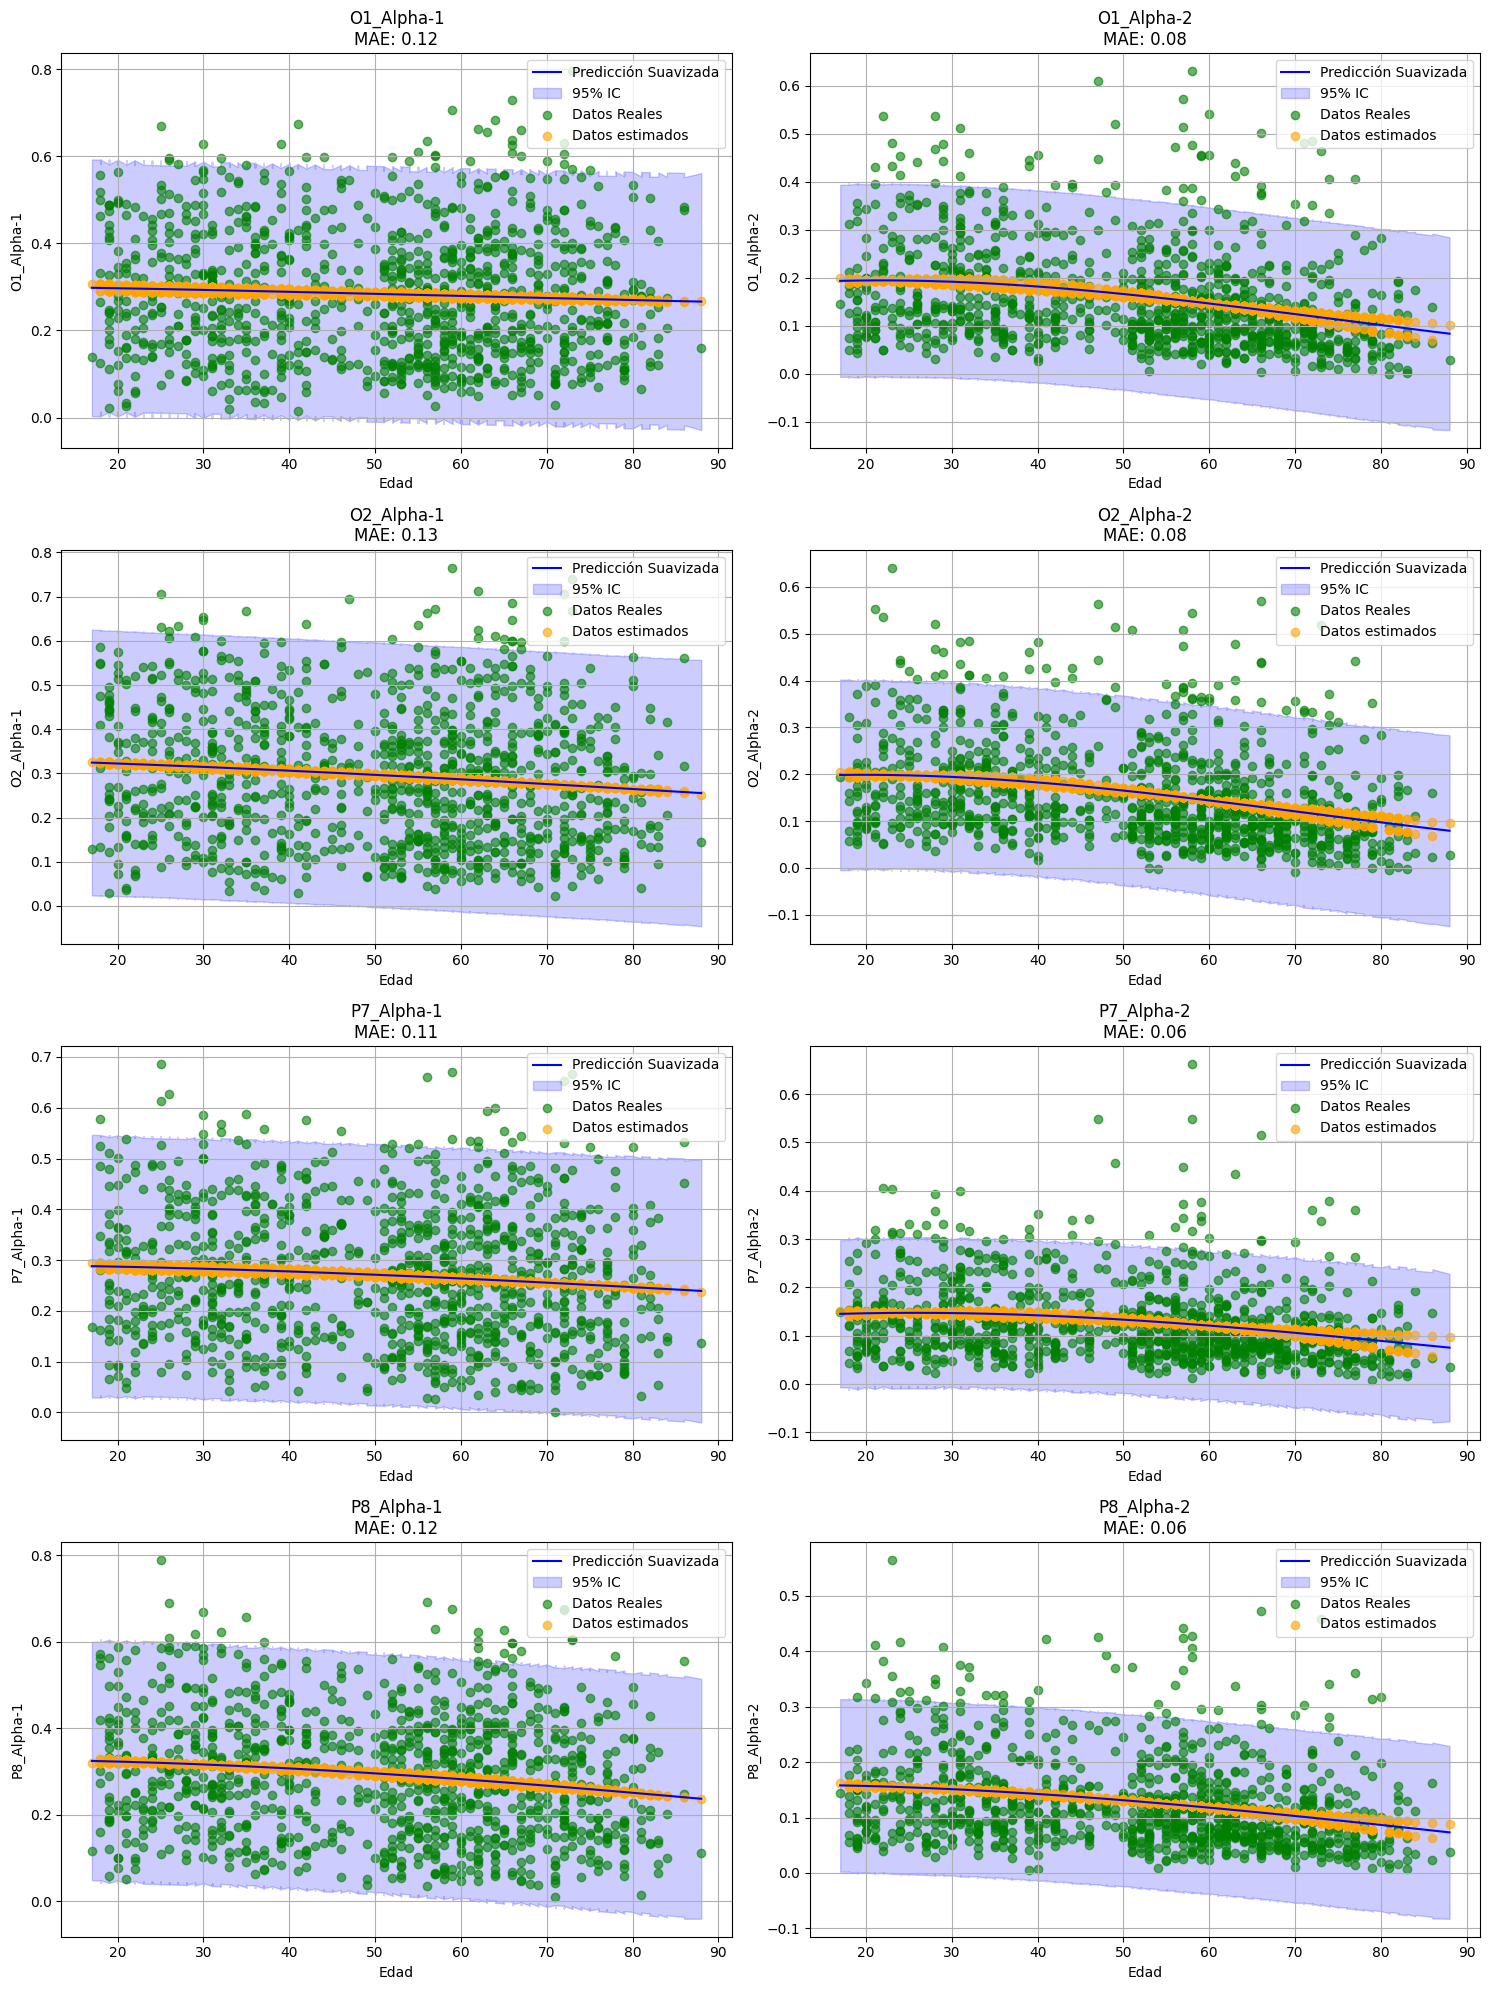

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from sklearn.metrics import mean_absolute_error, r2_score

# Constantes
z = 1.96  # Valor Z para un intervalo de confianza del 95%

# Cargar los datos
covariates = pd.read_csv(processing_dir+'/covariate_normsample_eeg.txt', sep=' ', header=None, names=['age'])
real_data = pd.read_csv(processing_dir+'/features_normsample_eeg.txt', sep=' ', header=None)
yhat = pd.read_csv(processing_dir+'/yhat_2fold.txt', sep=' ', header=None)
s2 = pd.read_csv(processing_dir+'/ys2_2fold.txt', sep=' ', header=None)

# Verificar tamaños de los DataFrames
print(len(feature_names_parietal_occipital)) 
print(len(feature_names_parietal_occipital))
print(len(feature_names_parietal_occipital))

# Extraer la edad y ordenar por edad
age = covariates['age']
sorted_indices = np.argsort(age)
age_sorted = age.iloc[sorted_indices]

# Crear subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

# Iterar sobre las características
for idx, feature in enumerate(feature_names_parietal_occipital):
    feature_index = idx  # Índice de la característica actual
    
    # Validar índices dentro del rango de columnas
    if feature_index >= real_data.shape[1] or feature_index >= yhat.shape[1] or feature_index >= s2.shape[1]:
        print(f"Índice {feature_index} fuera de rango para {feature}.")
        continue
    
    # Extraer datos de la característica
    yhat_feature = yhat.iloc[:, feature_index].values
    s2_feature = s2.iloc[:, feature_index].values
    real_data_feature = real_data.iloc[:, feature_index].values
    
    # Ordenar por edad
    yhat_sorted = yhat_feature[sorted_indices]
    s2_sorted = s2_feature[sorted_indices]
    real_data_sorted = real_data_feature[sorted_indices]
    # Aplicar suavizado con spline
    spline = UnivariateSpline(age_sorted, yhat_sorted, s=1)
    yhat_smooth = spline(age_sorted)
    
    # Calcular MAE 
    mae = mean_absolute_error(real_data_sorted, yhat_sorted)
    
    # Graficar
    ax = axes[idx]
    ax.plot(age_sorted, yhat_smooth, label='Predicción Suavizada', color='blue')
    ax.fill_between(age_sorted, yhat_smooth - z * np.sqrt(s2_sorted), 
                    yhat_smooth + z * np.sqrt(s2_sorted), color='blue', alpha=0.2, label='95% IC')
    ax.scatter(age_sorted, real_data_sorted, color='green', label='Datos Reales', alpha=0.6)
    ax.scatter(age_sorted, yhat_sorted, color='orange', label='Datos estimados', alpha=0.6)
    
    # Personalizar el gráfico
    ax.set_xlabel('Edad')
    ax.set_ylabel(feature)
    ax.set_title(f'{feature}\nMAE: {mae:.2f}')

    ax.legend()
    ax.grid(True)

# Ajustar diseño
plt.tight_layout()
plt.show()


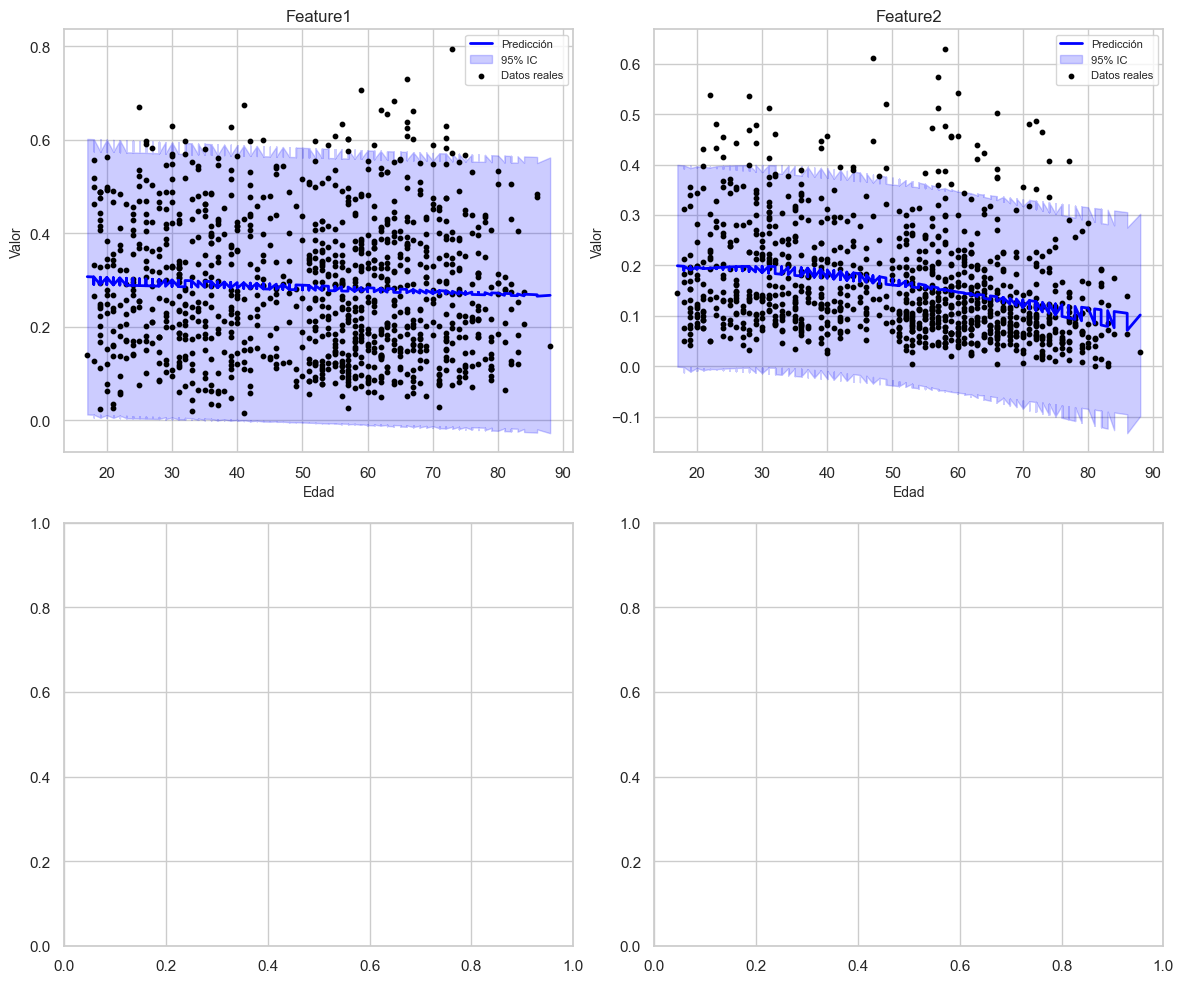

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Función para cargar datos
def load_data(file_path):
    """Carga los datos desde un archivo."""
    return pd.read_csv(file_path, sep=' ', header=None)


feature_names = feature_names_parietal_occipital

# Carga de datos
covariates = load_data(f"{processing_dir}/covariate_normsample_eeg.txt")
real_data = load_data(f"{processing_dir}/features_normsample_eeg.txt")
yhat = load_data(f"{processing_dir}/yhat_2fold.txt")
s2 = load_data(f"{processing_dir}/ys2_2fold.txt")

age = covariates.iloc[:, 0]
sorted_indices = np.argsort(age)
age_sorted = age.iloc[sorted_indices]

# Configuración del gráfico
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2x2 subplots
axes = axes.flatten()

for idx, feature_name in enumerate(feature_names):
    if idx >= real_data.shape[1]:
        break

    # Datos ordenados por edad
    real_data_feature = real_data.iloc[:, idx].values[sorted_indices]
    yhat_feature = yhat.iloc[:, idx].values[sorted_indices]
    s2_feature = s2.iloc[:, idx].values[sorted_indices]

    # Gráfica individual
    ax = axes[idx]
    z = 1.96  # Intervalo de confianza del 95%

    ax.plot(age_sorted, yhat_feature, color='blue', label='Predicción', linewidth=2)
    ax.fill_between(
        age_sorted,
        yhat_feature - z * np.sqrt(s2_feature),
        yhat_feature + z * np.sqrt(s2_feature),
        color='blue',
        alpha=0.2,
        label='95% IC'
    )
    ax.scatter(age_sorted, real_data_feature, color='black', s=10, label='Datos reales')
    ax.set_title(feature_name, fontsize=12)
    ax.set_xlabel("Edad", fontsize=10)
    ax.set_ylabel("Valor", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True)

# Ajustar y mostrar
plt.tight_layout()
plt.show()
